# <img style="float: left; padding-right: 15px; width: 35px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> CS 1090B: Advanced Topics in Data Science

# Homework 5: Building a Domain-Specific Language Model

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, Chris Gumb

<hr style="height:2pt">

<div style="background-color:#fff3cd; color:#222222; border:1px solid #ffeeba; padding:12px 14px; border-radius:10px; margin:10px 0;">
<strong>Running the Notebook:</strong> This homework involves training and fine-tuning language models. It was specifically designed to be run on <strong>Google Colab with a T4 GPU</strong> (free tier is sufficient). Total training time: approximately 30–45 minutes across all parts. The Setup cell below will mount your Google Drive so checkpoints persist across sessions. With this caching, you only need to train each model once.
</div>

<div style="background-color:#d1ecf1; color:#222222; border:1px solid #bee5eb; padding:12px 14px; border-radius:10px; margin:10px 0;">
<strong>Checkpointing:</strong> Staff-trained model checkpoints are provided for each part. They server as an example of what these models might achieve with a bit more training.
</div>

## Notebook Contents
<a id="contents"></a>

- [**Part 0: Domain Setup**](#part0) [8 Points]
- [**Part 1: Training from Scratch**](#part1) [20 Points]
- [**Part 2: Transfer Learning via Fine-Tuning**](#part2) [25 Points]
- [**Part 3: Instruction Tuning for Chat**](#part3) [25 Points]
- [**Part 4 (AC 209 Only): Preference Alignment with DPO**](#part4) [25 Points]
- [**Part 5: Illustrated Chatbot with Vision Transformers**](#part5) [26 Points]
- [**Part 6: Image Generation with Diffusion Models**](#part6) [20 Points]

**Total: 124 Points** (+ 25 for AC 209)

## Introduction

Welcome to the final homework of CS 1090B! It brings together concepts from our lectures on transformers, GPT, InstructGPT, vision transformers, and diffusion models. Our task is to implement each stage of a (toy) AI development pipeline:

1. **Training from scratch**: Train GPT-2 Medium from random initialization to see the challenges firsthand
2. **Transfer learning**: Fine-tune the same architecture with pretrained weights on a niche domain
3. **Instruction tuning**: Convert the model into a helpful chat assistant using supervised fine-tuning
4. **(AC 209) Preference alignment**: Use human preference data to improve response quality with DPO
5. **Visual augmentation**: Extend your assistant with image retrieval using CLIP Vision Transformers
6. **Image generation**: Use diffusion models to create images when retrieval fails



**Domain:** We'll work with a curated **natural history corpus** combining historical texts and field guide descriptions, plus associated nature images. This domain is distinctive enough to show clear before/after differences when adapting models.

By the end, you'll have a text chatbot augmented with CLIP-based image retrieval and diffusion-based image generation.

---

## Setup

In [1]:
# Check if we're running in Colab
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import os
    from google.colab import drive

    # Pin package versions to match the course environment.
    # NOTE: after this installs, Colab may prompt you to restart the runtime.
    # Do so, then re-run this cell before continuing.
    %pip install -q "transformers>=4.40.0" datasets tokenizers accelerate evaluate "trl>=0.12"
    %pip install -q matplotlib seaborn pandas numpy tqdm pillow
    %pip install -q diffusers  # Needed for Part 6 (Diffusion Models)

    # Mount Drive — authenticate once; checkpoints persist across sessions
    drive.mount("/content/drive")

    # Persistent hw5 directory on Drive
    HW5_DIR = "/content/drive/MyDrive/CS1090B/hw5"
    os.makedirs(os.path.join(HW5_DIR, "checkpoints"), exist_ok=True)

    # Where to save/load model checkpoints — persists across Colab sessions
    CHECKPOINT_DIR = os.path.join(HW5_DIR, "checkpoints")

    # Confirm GPU — select Runtime > Change runtime type > T4 GPU if not shown
    import torch
    if torch.cuda.is_available():
        print(f"\nGPU ready: {torch.cuda.get_device_name(0)}")
    else:
        print("\nWARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

else:
    import os
    CHECKPOINT_DIR = "./checkpoints"  # local: save checkpoints next to notebook

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Checkpoint directory: ./checkpoints


In [2]:
# Imports
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# HuggingFace
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    GPT2Config,
    GPT2LMHeadModel,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from datasets import load_dataset, Dataset as HFDataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA L4


### Configuration

The cell below centralizes key hyperparameters and paths for the entire homework. When a question says "use the configured learning rate" or "load the staff checkpoint," it refers to values defined here. Feel free to experiment with these settings, but the defaults are tuned to work within the Colab T4 time budget.

In [3]:
# Configuration
class Config:
    """Central configuration for the homework"""

    # Data settings
    DOMAIN = "natural_history"
    MAX_SAMPLES_TRAIN = 2000  # Small subset for practice (staff models use full dataset)
    MAX_LENGTH = 512           # Maximum sequence length

    # Model — GPT-2 Medium is used throughout (Parts 1-4)
    MODEL_NAME = "gpt2-medium"

    # Training settings
    BATCH_SIZE = 2
    GRADIENT_ACCUMULATION_STEPS = 4  # effective batch = BATCH_SIZE * 4 = 8
    LEARNING_RATE_SCRATCH = 1e-4    # Part 1: higher LR for random init
    LEARNING_RATE_FINETUNE = 5e-5   # Part 2: lower LR to preserve pretrained knowledge
    NUM_EPOCHS_SCRATCH = 2          # Part 1: limited epochs (random init, slow convergence)
    NUM_EPOCHS_FINETUNE = 3         # Part 2: fine-tuning converges faster
    NUM_EPOCHS_INSTRUCT = 3         # Part 3: instruction tuning

    # Paths — CHECKPOINT_DIR is set in the Setup cell above

    # Staff checkpoints on HuggingFace Hub — use these if your own training
    # fails or takes too long. Each is a full model loadable with from_pretrained().
    STAFF_PART1_HUB = "cs1090b/hw5-part1-scratch"
    STAFF_PART2_HUB = "cs1090b/hw5-part2-domain-adapted"
    STAFF_PART3_HUB = "cs1090b/hw5-part3-sft"
    STAFF_PART4_HUB = "cs1090b/hw5-part4-aligned"

    # Datasets on HuggingFace Hub
    PREFERENCE_DATASET_HUB = "cs1090b/natural-history-preferences"

config = Config()

### The Full Pipeline

In this homework, you'll build each stage of the following AI pipeline:

```
┌─────────────┐    ┌─────────────┐    ┌─────────────┐    ┌─────────────┐
│   Part 1    │    │   Part 2    │    │   Part 3    │    │   Part 4    │
│  Train from │───►│ Fine-tune   │───►│ Instruction │───►│  Preference │
│  scratch    │    │ pretrained  │    │ tuning (SFT)│    │ alignment   │
│             │    │ on domain   │    │ with Q&A    │    │ with DPO    │
└─────────────┘    └─────────────┘    └─────────────┘    └──────┬──────┘
                                                                │
                   ┌─────────────┐    ┌─────────────┐          │
                   │   Part 6    │    │   Part 5    │          │
                   │  Generate   │◄───│ Retrieve    │◄─────────┘
                   │  images w/  │    │ images w/   │
                   │  Diffusion  │    │ CLIP        │
                   └─────────────┘    └─────────────┘
```

At each stage, you'll:
1. See the model's output **before** the step (to understand what changes)
2. **Train** or configure the model yourself
3. **Evaluate** the improvement with sample outputs
4. **Load the staff model** (trained longer) to compare what's possible with more training and to use as a strong baseline going forward

---

<a id="part0"></a>
## Part 0: Domain Setup and Corpus Analysis [6 Points]

Before training any models, we need to understand our data. In this part you'll explore the **natural history corpus** — a collection of classic texts by Darwin, Wallace, Audubon, and Thoreau, plus thousands of Wikipedia biology articles.

The choice and quality of training data significantly impacts model performance. A good domain corpus should have distinctive vocabulary and style that clearly differentiate it from general web text.

### Q0.1 - Load and Explore the Domain Corpus [3 Points]

Load the natural history corpus from HuggingFace Hub and display basic information about it. The dataset is hosted at `cs1090b/natural-history-corpus` — a curated collection of classic natural history texts and biology articles.

**Deliverables:**
1. Load the dataset using [`load_dataset()`](https://huggingface.co/docs/datasets/loading) with dataset ID `"cs1090b/natural-history-corpus"` and `split="train"` into a variable `raw_dataset`
2. Print the total number of examples
3. Display the first example (first 300 characters)

**Hint:** The dataset is a standard HuggingFace dataset with a `"text"` column. Use `raw_dataset[0]` to inspect the first example.

In [ ]:
# Load the domain corpus from HuggingFace Hub
# This contains Project Gutenberg natural history books (Darwin, Wallace,
# Audubon, Thoreau, etc.) + Wikipedia biology/ecology articles.

print("Loading natural history corpus...")
raw_dataset = load_dataset("cs1090b/natural-history-corpus", split="train")

print(f"Loaded {len(raw_dataset)} examples")
print(f"\nFirst example (first 300 chars):")
print(raw_dataset[0]['text'][:300])


Loading natural history corpus...


Loaded 4508 examples

First example (first 300 chars):
AstralSat, also known as DTH Interactive Telecomunicação Ltda, is or was a satellite television service in Brazil that was the first such service in that country to offer prepaid subscription TV.

It reportedly suspended operations in 2010.

The service launched a plan of 12 channels for R$30 per mo


### Q0.2 - Corpus Statistics and Visualization [3 Points]

Compute and visualize text statistics to understand the corpus distribution. This kind of data exploration is essential before training with sequence data.

**Deliverables:**
1. Implement `analyze_corpus()` to compute:
    - number of documents
    - total characters
    - average/std character length
    - total words (estimated, non-unique)
    - average word count
2. Display statistics in a summary table
3. Create a histogram and box plot of text lengths using `matplotlib`

**Hint:** You can just use `len(text.split())` for word count estimates. Text length distributions are often heavily skewed — consider using a log scale on the x-axis to make the shape more readable.

In [5]:
def analyze_corpus(dataset, num_samples=1000):
    """Compute basic statistics about the corpus"""
    texts = [ex['text'] for ex in dataset.select(range(min(num_samples, len(dataset))))]
    char_lengths = [len(t) for t in texts]
    word_counts  = [len(t.split()) for t in texts]
    return {
        "num_documents":      float(len(texts)),
        "total_characters":   float(sum(char_lengths)),
        "avg_char_length":    float(sum(char_lengths) / len(char_lengths)),
        "std_char_length":    float(pd.Series(char_lengths).std()),
        "total_words":        float(sum(word_counts)),
        "avg_word_count":     float(sum(word_counts) / len(word_counts)),
    }

stats = analyze_corpus(raw_dataset)

# Display statistics
print("Corpus Statistics:")
print("-" * 50)
for key, value in stats.items():
    print(f"{key:20s}: {value:,.2f}")


Corpus Statistics:
--------------------------------------------------
num_documents       : 1,000.00
total_characters    : 6,147,355.00
avg_char_length     : 6,147.35
std_char_length     : 23,138.01
total_words         : 959,195.00
avg_word_count      : 959.20


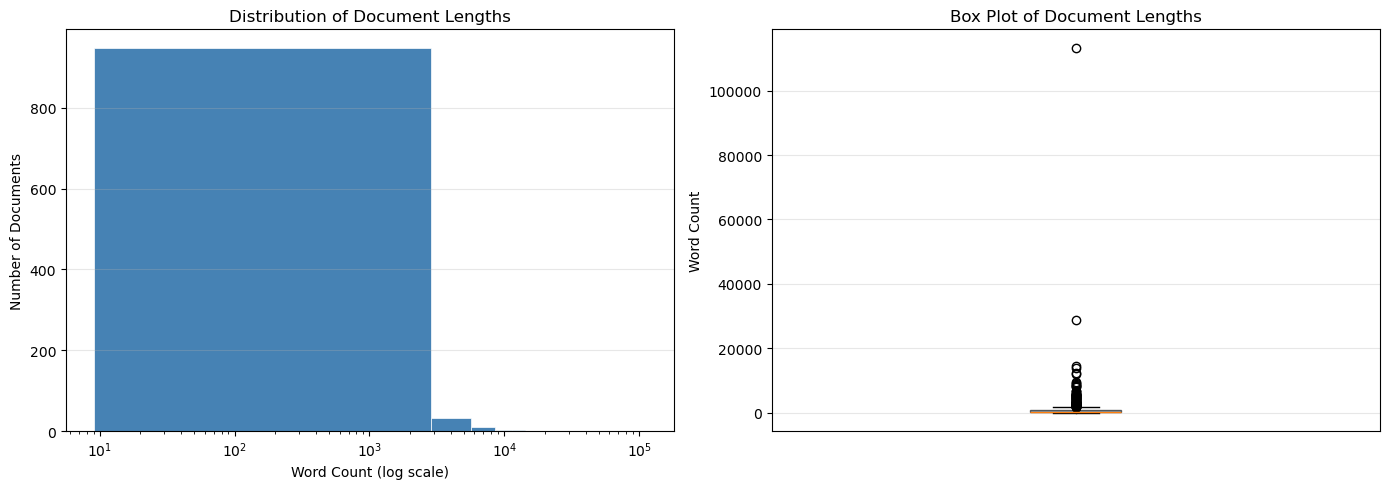

In [6]:
def plot_length_distribution(dataset, num_samples=1000):
    """Plot distribution of text lengths"""
    texts = [ex['text'] for ex in dataset.select(range(min(num_samples, len(dataset))))]
    lengths = [len(t.split()) for t in texts]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # Histogram (log x-scale to handle heavy right tail)
    ax1.hist(lengths, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    ax1.set_xscale('log')
    ax1.set_xlabel('Word Count (log scale)')
    ax1.set_ylabel('Number of Documents')
    ax1.set_title('Distribution of Document Lengths')
    ax1.grid(axis='y', alpha=0.3)
    # Box plot
    ax2.boxplot(lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax2.set_ylabel('Word Count')
    ax2.set_title('Box Plot of Document Lengths')
    ax2.set_xticks([])
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_length_distribution(raw_dataset)


### Q0.3 - Explore the Corpus [Provided]

Let's look at some actual passages from the corpus. Read through these examples and notice what makes them distinctive: specialized vocabulary, taxonomic names, descriptive natural language, and varying writing styles from different eras.


In [7]:
import textwrap

# Display a few passages so you can see what the model will learn from
random.seed(42)
sample_indices = random.sample(range(len(raw_dataset)), 5)

for i, idx in enumerate(sample_indices):
    text = raw_dataset[idx]['text']
    print(f"{'='*70}")
    print(f"Passage {i+1} (document {idx}, {len(text.split())} words)")
    print(f"{'='*70}")
    # Show first 500 characters with wrapping
    preview = text[:500] + ('...' if len(text) > 500 else '')
    print(textwrap.fill(preview, width=78))
    print()


Passage 1 (document 912, 47 words)
Nawabganj may refer to:  Bangladesh  Nawabganj Town, administrative centre of
Chapai Nawabganj District, Bangladesh  Chapai Nawabganj District  Nawabganj
Upazila, Dhaka  Nawabganj Upazila, Dinajpur  India  Uttar Pradesh Nawabganj
Bird Sanctuary, Unnao District Nawabganj, Barabanki, a tehsil Nawabganj,
Bareilly Nawabganj, Gonda Nawabganj, Unnao  West Bengal Nawabganj, North 24
Parganas

Passage 2 (document 204, 1210 words)
Gahirmatha Beach () is a beach in Kendrapara district of the Indian state of
Odisha. The beach separates the Bhitarkanika Mangroves from the Bay of Bengal
and is the world's most important nesting beach for olive ridley sea turtles.
The beach is part of Gahirmatha Marine Wildlife Sanctuary, which also includes
the adjacent portion of the Bay of Bengal.  Location Gahirmatha is the only
marine wildlife sanctuary of Odisha. This was notified as such in Government
of Odisha, Forest & Environment Dep...

Passage 3 (document 2253, 720 word

---

<a id="part1"></a>
## Part 1: Training from Scratch [20 Points]

In this part, you'll train GPT-2 Medium (355M parameters) starting from **randomly initialized weights** — no pretraining, no prior knowledge. This implements core concepts: causal masking, next-token prediction, autoregressive generation.

Training from scratch on our small domain corpus for just a few epochs will demonstrate how much (or how little) a large model can learn without the benefit of pretraining. This sets up a direct, fair comparison with Part 2, where you'll use the **exact same architecture** but start from pretrained weights instead.

**Key API:** [`GPT2Config`](https://huggingface.co/docs/transformers/model_doc/gpt2#transformers.GPT2Config), [`GPT2LMHeadModel`](https://huggingface.co/docs/transformers/model_doc/gpt2#transformers.GPT2LMHeadModel), and [`Trainer`](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.Trainer)

### Q1.1 - Initialize GPT-2 Medium with Random Weights [2 Points]

Create a GPT-2 Medium model with **random weights** using HuggingFace's `GPT2Config` and `GPT2LMHeadModel`. The key distinction: we use `GPT2Config.from_pretrained()` to get the architecture specification (24 layers, 16 heads, 1024 hidden dim) but then create the model with `GPT2LMHeadModel(config)` — NOT `from_pretrained()` — so the weights start random.

**Deliverables:**
1. Load the GPT-2 tokenizer and the GPT-2 Medium architecture config using `config.MODEL_NAME` from the Config cell
2. Create a `GPT2LMHeadModel` from this config (random weights, not pretrained)
3. Print the total parameter count

**Hint:** `GPT2Config.from_pretrained("gpt2-medium")` gives you the architecture. `GPT2LMHeadModel(gpt2_config)` gives you a randomly initialized model with that architecture. This is ~355M parameters.

In [8]:
# Load GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

# Get GPT-2 Medium architecture config (but NOT pretrained weights)
gpt2_config = GPT2Config.from_pretrained(config.MODEL_NAME)

# Create model with random weights — this is NOT from_pretrained()
scratch_model = GPT2LMHeadModel(gpt2_config)
scratch_model.to(device)

# Count parameters
total_params = sum(p.numel() for p in scratch_model.parameters())
print(f"GPT-2 Medium (random init) parameters: {total_params:,} (~{total_params / 1e6:.1f}M)")
print(f"Architecture: {gpt2_config.n_layer} layers, {gpt2_config.n_head} heads, {gpt2_config.n_embd} hidden dim")


GPT-2 Medium (random init) parameters: 354,823,168 (~354.8M)
Architecture: 24 layers, 16 heads, 1024 hidden dim


### Q1.2 - Prepare Training Data [Provided]

Before training, we need to convert raw text into token IDs that the model can process. Recall from lecture that GPT uses byte-pair encoding (BPE): common words become single tokens, while rare words get split into subword pieces. The tokenizer converts text to a sequence of integer IDs, and the model learns to predict the next token in the sequence.

The code below tokenizes the corpus. After running it, look at the example output to see how the tokenizer handles domain-specific vocabulary like species names — these often get split into multiple subword tokens.

In [9]:
# Filter and limit dataset
texts = [ex['text'] for ex in raw_dataset if len(ex['text'].split()) > 10]
if len(texts) > config.MAX_SAMPLES_TRAIN:
    texts = texts[:config.MAX_SAMPLES_TRAIN]

print(f"Prepared {len(texts)} training examples")

# Tokenize
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=config.MAX_LENGTH,
        padding="max_length",
    )

train_dataset = HFDataset.from_dict({"text": texts})
tokenized_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

print(f"Tokenized {len(tokenized_dataset)} examples")

# Show what tokenization looks like — how does the model see text?
sample_text = texts[0][:200]
tokens = tokenizer.encode(sample_text)
print(f"\nTokenization example:")
print(f"  Original text:  {sample_text[:100]}...")
print(f"  Token IDs:      {tokens[:20]}...")
print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in tokens[:15]]}...")
print(f"  {len(sample_text)} characters → {len(tokens)} tokens")

Prepared 2000 training examples


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized 2000 examples

Tokenization example:
  Original text:  AstralSat, also known as DTH Interactive Telecomunicação Ltda, is or was a satellite television serv...
  Token IDs:      [33751, 1373, 20245, 11, 635, 1900, 355, 360, 4221, 21365, 44021, 403, 3970, 16175, 28749, 19090, 6814, 11, 318, 393]...
  Decoded tokens: ['Ast', 'ral', 'Sat', ',', ' also', ' known', ' as', ' D', 'TH', ' Interactive', ' Telecom', 'un', 'ica', 'ç', 'ão']...
  200 characters → 46 tokens


### Q1.3 - Train from Scratch [6 Points]

We now train our randomly initialized GPT-2 Medium on the natural history corpus. This is the most time-consuming step: the model starts knowing nothing — not even basic grammar — and must learn everything from our small dataset.

We use HuggingFace's [`Trainer`](https://huggingface.co/docs/transformers/main_classes/trainer) API, which handles the training loop, gradient accumulation, and checkpointing. We also use **mixed precision** (`fp16`), which stores model weights in 16-bit floating point during training — this roughly halves GPU memory usage and speeds up training on modern GPUs with minimal impact on quality.

**Deliverables:**
1. Configure [`TrainingArguments`](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments) — use the learning rate and epoch count from `config` (see the Config cell). Set `fp16=True` for mixed precision on GPU.
2. Create a `Trainer` with the model, training args, dataset, and a [`DataCollatorForLanguageModeling`](https://huggingface.co/docs/transformers/main_classes/data_collator#transformers.DataCollatorForLanguageModeling) (with `mlm=False` for causal LM)
3. Call `trainer.train()` and capture the result

**Hint:** The configured learning rate (`config.LEARNING_RATE_SCRATCH = 1e-4`) is higher than what we'll use for fine-tuning in Part 2 — random weights need larger updates to learn anything at all. Training for `config.NUM_EPOCHS_SCRATCH` (2) epochs takes ~15-20 minutes on a T4.

In [10]:
# Before training: see what a randomly initialized model produces
print("=== BEFORE TRAINING (random weights) ===")
print("The model has never seen any data — its outputs are pure noise.\n")

test_prompt = "The birds of the tropical forest"
inputs = tokenizer(test_prompt, return_tensors="pt").to(device)
scratch_model.eval()
with torch.no_grad():
    output = scratch_model.generate(**inputs, max_new_tokens=50, do_sample=True,
                                temperature=0.8, pad_token_id=tokenizer.eos_token_id,
                                repetition_penalty=1.3)
print(f"Prompt: {test_prompt}")
print(f"Output: {tokenizer.decode(output[0], skip_special_tokens=True)}")
print("\n(This should be gibberish — the model hasn't learned anything yet.)")

=== BEFORE TRAINING (random weights) ===
The model has never seen any data — its outputs are pure noise.

Prompt: The birds of the tropical forest
Output: The birds of the tropical forestiphateraftedreleased Cancer CHOoots Aven stren Lansing PLAadelMakingDirectoretusECD CHO Woo levied reliablyiners rhetoricoving Wellingtonannot ripple spores Indians lenders Guardiolatarget deal embraces mightycoon Roe hoc Lazarus reliably 1907 MalWA} gren infectbsimaru testimemail discredited Davies

(This should be gibberish — the model hasn't learned anything yet.)


In [ ]:
# Check for cached checkpoint first — skip training if already done
checkpoint_path = os.path.join(CHECKPOINT_DIR, "part1_scratch")

if os.path.exists(os.path.join(checkpoint_path, "model.safetensors")):
    print(f"Found existing checkpoint at {checkpoint_path}, loading...")
    scratch_model = AutoModelForCausalLM.from_pretrained(checkpoint_path)
    scratch_model.to(device)
    print("Loaded cached model (skipping training).")
else:
    training_args = TrainingArguments(
        output_dir=os.path.join(CHECKPOINT_DIR, "outputs", "scratch_model"),
        num_train_epochs=config.NUM_EPOCHS_SCRATCH,            # Try config.NUM_EPOCHS_SCRATCH
        per_device_train_batch_size=config.BATCH_SIZE,         # Try config.BATCH_SIZE
        gradient_accumulation_steps=config.GRADIENT_ACCUMULATION_STEPS,  # Try config.GRADIENT_ACCUMULATION_STEPS
        learning_rate=config.LEARNING_RATE_SCRATCH,            # Try config.LEARNING_RATE_SCRATCH
        logging_steps=50,
        save_strategy="epoch",
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False) # causal lm

    trainer = Trainer(
        model=scratch_model,
        args=training_args,
        train_dataset=tokenized_dataset,
        data_collator=data_collator,
    )

    print("Training GPT-2 Medium from scratch (random init)...")
    print("Expected time: ~15-20 minutes on T4 GPU")
    print("(Your model trains on a small subset; the staff model was trained on much more data.)\n")

    train_result = trainer.train()

    # Save for future runs
    scratch_model = trainer.model
    scratch_model.save_pretrained(checkpoint_path)
    tokenizer.save_pretrained(checkpoint_path)
    print(f"\nModel saved to {checkpoint_path}")


Found existing checkpoint at ./checkpoints/part1_scratch, loading...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded cached model (skipping training).


(Loaded from cache — showing saved training plot.)


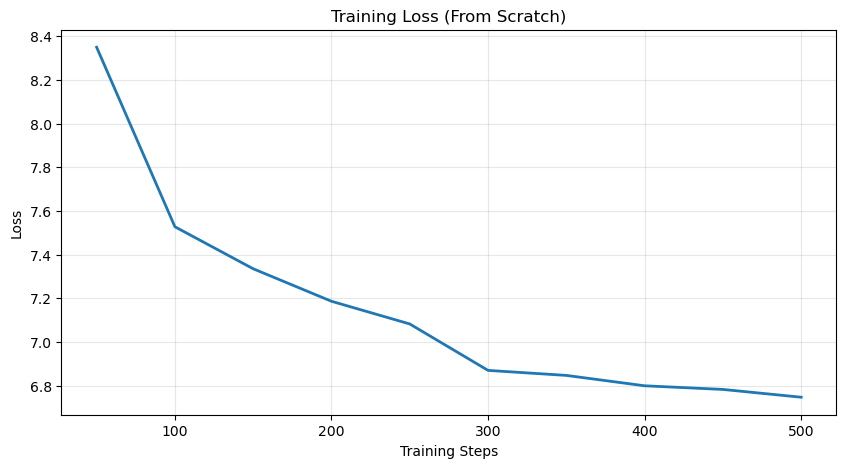

In [12]:
# Skip if model was loaded from cache (no training history)
try:
    trainer.state
except (NameError, AttributeError):
    # Show saved plot from checkpoint if available
    plot_path = os.path.join(checkpoint_path, "training_loss.png")
    if os.path.exists(plot_path):
        print("(Loaded from cache — showing saved training plot.)")
        from IPython.display import Image, display
        display(Image(filename=plot_path))
    else:
        print("Model was loaded from cache — no training loss to plot.")
else:
    # Plot training loss
    train_logs = trainer.state.log_history
    losses = [log['loss'] for log in train_logs if 'loss' in log]
    steps = [log['step'] for log in train_logs if 'loss' in log]

    if losses:
        plt.figure(figsize=(10, 5))
        plt.plot(steps, losses, linewidth=2)
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.title('Training Loss (From Scratch)')
        plt.grid(alpha=0.3)
        plot_path = os.path.join(checkpoint_path, "training_loss.png")
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"Final training loss: {losses[-1]:.4f}")
    else:
        print("No training loss logged (try reducing logging_steps or training longer)")

### Q1.4 - Evaluate and Generate Text [6 Points]

Now let's see what our from-scratch model actually learned. We'll generate text from several prompts and evaluate the quality. Even with 355M parameters, a model trained from scratch on a small dataset for 2 epochs will produce text with obvious problems — repetition, topic drift, grammatical errors.

**Deliverables:**
1. Implement `generate_text()` using [`model.generate()`](https://huggingface.co/docs/transformers/main_classes/text_generation) with temperature sampling
2. Generate text from 3 domain-relevant prompts: `"The birds of"`, `"In the forest"`, `"The species"`
3. Display the generated text for each prompt

**Hint:** For `generate()`, key parameters are `max_new_tokens`, `temperature` (higher = more random), `do_sample=True`, and `top_k` or `top_p`. Set `pad_token_id=tokenizer.eos_token_id` to suppress warnings.

In [13]:
def generate_text(model, tokenizer, prompt, max_length=100, temperature=0.8):
    """Generate text from the model"""
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=temperature,
            do_sample=True,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.3,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

prompts = ["The bird", "In the forest", "The species"]

print("=" * 70)
print("FROM-SCRATCH MODEL GENERATIONS")
print("=" * 70)

for prompt in prompts:
    generated = generate_text(scratch_model, tokenizer, prompt)

    # generated = generate_text(scratch_model, tokenizer, prompt)

    print(f"\nPrompt: '{prompt}'")
    print(f"Generated: {generated}")
    print("-" * 70)


FROM-SCRATCH MODEL GENERATIONS

Prompt: 'The bird'
Generated: The bird is a park of the species. It has known in the genus are other species as an family and  or length, but found to be in many common in two white that was named to water and its species of both the genus, with a same have often used for their genus.

A name of the "Ky in the large in the population. The name species. His  It are also by the South Zealand of the American leaves is a time, which and other species, the
----------------------------------------------------------------------

Prompt: 'In the forest'
Generated: In the forest was an first was a " song to his " B.
The American United, a following by his D in the World) were well as 17ü and it with both he who they at North of the Australian number to the  In the same University and her became him to the first was been made its family in 16-born National name, with an New K-based's series and not his album after the French, this-Son, at the father-P. He had also

### Compare with Staff Model

Now let's compare with the staff-trained from-scratch model, which was trained on the
full dataset for more epochs — observe how more training data and compute improves output quality.

In [14]:
# Load staff-trained From-Scratch GPT-2 for comparison
print("Loading staff-trained From-Scratch GPT-2...")
staff_scratch_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART1_HUB)
staff_scratch_tokenizer = AutoTokenizer.from_pretrained(config.STAFF_PART1_HUB)
staff_scratch_model.to(device)
staff_scratch_model.eval()

print("\n" + "=" * 70)
print("COMPARISON: Your From-Scratch GPT-2 vs Staff From-Scratch GPT-2")
print("=" * 70)

for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")

    yours = generate_text(scratch_model, tokenizer, prompt)
    print(f"  Your model:  {yours}")

    staff = generate_text(staff_scratch_model, staff_scratch_tokenizer, prompt)
    print(f"  Staff model: {staff}")

# Clean up to free GPU memory
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading staff-trained From-Scratch GPT-2...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


COMPARISON: Your From-Scratch GPT-2 vs Staff From-Scratch GPT-2

Prompt: 'The bird'
  Your model:  The birdiaa (Sidae is a family, the  species from New genus of the village in the area. It is been as a species, and found to that the Southkm. The species of two-likeom, with a white and the southern large park and more sub America, and their small be have it are which are on the head of the long can .


A, in G-Plodis. They than this.
External links
E.
Taxan
  Staff model: The bird of the male is
long-shaped colour, with its wings and long legs. The females are generally so
been much more striking than a duller of each other to have been formed in size. As when
the female has a strong lower surface than that of both sexes as distinct
species, it may be said by Mr. Smith (‘Proceedings on the Zoological Society of Species) they
generally become different from the two and five or three species; but these

Prompt: 'In the forest'
  Your model:  In the forest, a order. The American town of 

### Q1.5 - Explore and Analyze: Training from Scratch [6 Points]

Try two prompts of your own choosing and compare outputs from your model vs. the staff model. Then answer the analysis question below.

In [15]:
# Load staff model for comparison

# Try your own prompts — pick two that relate to natural history
my_prompts = [
    "The migration of monarch butterflies",
    "Coral reefs support",
]

print("=" * 70)
print("YOUR PROMPTS: Your Model vs Staff Model")
print("=" * 70)
for prompt in my_prompts:
    print(f"\nPrompt: '{prompt}'")
    yours = generate_text(scratch_model, tokenizer, prompt)
    print(f"  Your model:  {yours}")
    staff = generate_text(staff_scratch_model, staff_scratch_tokenizer, prompt)
    print(f"  Staff model: {staff}")

del staff_scratch_model, staff_scratch_tokenizer
torch.cuda.empty_cache() if torch.cuda.is_available() else None

YOUR PROMPTS: Your Model vs Staff Model

Prompt: 'The migration of monarch butterflies'
  Your model:  The migration of monarch butterflies (bornI- British family) is a southern species as the name to the 


Alon, or this name in the world. It was known from which has an same large years of 18km, the University of this small: New North park by two than it on a head and also named with the American family-like . The type genus of South America, found by the family, the name. As its plant described the first number of the United. The York and
  Staff model: The migration of monarch butterflies, including the family Scadovus nelus. It is located in the area with an average part of .
It occurs when the species has been recorded by this name in the genus Dipteraceae (Tiflora). The specific name for most other members of its own families are placed on all as a single species and subspecies, which include one group of the only three-dwellers' genus, but also have previously had no longer time

Based on the generated text from both your model and the staff model, identify two specific failure modes visible in the outputs (e.g., repetition loops, topic drift, broken syntax, incoherent references). 

For each, explain whether it is more likely caused by insufficient training data (~2000 documents) or insufficient training time (2 epochs), and why. 

How does the staff model (trained longer on more data) compare? (4-6 sentences)


<div style="background-color:#e8f4f8; border:2px solid #b8daff; padding:15px; border-radius:5px;">

**Your Answer to Q1.5:**

Two failure modes are visible in the from-scratch model outputs:

- **Incoherent references / topic drift:** On the prompt "The migration of monarch butterflies," the student model immediately drifts into describing a fictional family "(bornI- British family)" and then rambles about park sizes and American family names — completely unrelated to the topic. This failure is primarily caused by **insufficient training data (~2000 documents)**: the model never saw enough coherent long-form text about any single subject, so it cannot sustain a topic across a sentence.

- **Broken syntax and fragmented grammar:** Generations like "It is been as a species, and found to that the Southkm. The species of two-likeom" show garbled word order and nonsensical tokens. This is primarily caused by **insufficient training time (2 epochs)**: the model hasn't converged enough to learn basic English grammatical patterns — two epochs over a small corpus gives too few gradient updates to internalize even surface-level syntax.

**Staff model comparison:** The staff model (trained on more data for more epochs) shows clear improvement: its output on the same prompt reads as proper English prose and maintains the butterfly topic, though it still hallucinates biological details (e.g., "genus Dipteraceae"). More data and training time evidently gives the model the fluency and topic coherence that the student model entirely lacks, even if factual accuracy remains limited.

</div>

In [16]:
# Free Part 1 models and datasets — no longer needed
import gc

for name in ['scratch_model', 'tokenized_dataset', 'train_dataset', 'trainer']:
    if name in dir():
        exec(f'del {name}')

gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory after Part 1 cleanup: {torch.cuda.memory_allocated() / 1e9:.1f} GB")


GPU memory after Part 1 cleanup: 0.0 GB


---

> Your from-scratch model is complete. Even with 355M parameters, training from scratch on a small dataset for just 2 epochs produces mediocre results. In Part 2, we'll use the **exact same GPT-2 Medium architecture** but start from **pretrained weights** — this is the core idea of transfer learning.

<a id="part2"></a>
## Part 2: Transfer Learning via Fine-Tuning [25 Points]

In Part 1, you trained GPT-2 Medium from random weights — same architecture, 355M parameters, but no prior knowledge. Now you'll apply **transfer learning**: load the same GPT-2 Medium architecture but with **pretrained weights** from OpenAI's original training on a large web text corpus.

The pretrained model already understands English grammar, syntax, and general world knowledge. Fine-tuning adapts this general knowledge to our natural history domain. The key question: how much does pretraining matter? You'll see the answer directly by comparing your from-scratch model (Part 1) with the pretrained-then-fine-tuned model (this part) — same architecture, different starting points.

**Key API:** [`AutoModelForCausalLM.from_pretrained()`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForCausalLM) loads pretrained weights; [`TrainingArguments`](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments) controls fine-tuning behavior

### Q2.1 - Load Pretrained Model and Baseline [5 Points]

Load GPT-2 Medium using HuggingFace's [`AutoModelForCausalLM`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForCausalLM) and establish baseline performance *before* fine-tuning.

**Deliverables:**
1. Load the pretrained model and tokenizer using `config.MODEL_NAME` (`"gpt2-medium"`) with `AutoModelForCausalLM.from_pretrained()` and `AutoTokenizer.from_pretrained()`
2. Generate text from the same 3 prompts used in Part 1
3. Note how much better the pretrained model is — even without any domain-specific training. Same architecture, same parameter count, but pretrained weights vs. random init.

**Hint:** Set `tokenizer.pad_token = tokenizer.eos_token` — GPT-2 doesn't have a separate pad token.

In [17]:
model_name = "gpt2-medium"

pretrained_model = AutoModelForCausalLM.from_pretrained(model_name)
pretrained_tokenizer = AutoTokenizer.from_pretrained(model_name)


pretrained_tokenizer.pad_token = pretrained_tokenizer.eos_token
pretrained_model.to(device)

total_params = sum(p.numel() for p in pretrained_model.parameters())
print(f"Pretrained model: {model_name}")
print(f"Parameters: {total_params:,} (~{total_params / 1e6:.1f}M)")


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Pretrained model: gpt2-medium
Parameters: 354,823,168 (~354.8M)


In [18]:
# Baseline generations
print("=" * 70)
print("PRETRAINED MODEL (Before Fine-Tuning)")
print("=" * 70)

for prompt in prompts:
    generated = generate_text(pretrained_model, pretrained_tokenizer, prompt)
    print(f"\nPrompt: '{prompt}'")
    print(f"Generated: {generated}")
    print("-" * 70)

PRETRAINED MODEL (Before Fine-Tuning)

Prompt: 'The bird'
Generated: The bird has been on display at the aquarium since 2013.
 to be added

 and here is a selection of photos from this week's exhibition
----------------------------------------------------------------------

Prompt: 'In the forest'
Generated: In the forest, a small child was playing in the trees. A man who had been standing nearby said to his wife: "You saw that boy play?"
When he heard this comment from another woman's husband it immediately turned out that she too could tell something wasn't right about her son and father of four. In fact their whole family moved away after they realized what happened at home; not only did everyone move but also all relatives are now living abroad (not just children). Many have no idea how anything
----------------------------------------------------------------------

Prompt: 'The species'
Generated: The species in question is a small, medium-sized bird called the Paraceratops.
Coccu

### Q2.2 - Fine-Tune on Domain Corpus [10 Points]

Fine-tune **all parameters** of GPT-2 Medium on the natural history corpus. This is full fine-tuning — every weight in the model gets updated. (In practice, methods like [LoRA](https://arxiv.org/abs/2106.09685) freeze most parameters and only train small adapter matrices, which is faster and uses less memory. We use full fine-tuning here for simplicity since LoRA was not covered in class.)

The key difference from Part 1: the learning rate must be **much lower** (`config.LEARNING_RATE_FINETUNE = 5e-5` vs `1e-4`). Large updates would destroy the pretrained knowledge the model already has — a problem called **"catastrophic forgetting."**

**Deliverables:**
1. Tokenize the corpus with the pretrained tokenizer (same approach as Part 1)
2. Configure `TrainingArguments` — use `config.LEARNING_RATE_FINETUNE` and `config.NUM_EPOCHS_FINETUNE`
3. Train using `Trainer`
4. Plot training loss
5. Report final loss

In [19]:
# Prepare dataset with pretrained tokenizer
def tokenize_pretrained(examples):
    return pretrained_tokenizer(
        examples["text"],
        truncation=True,
        max_length=config.MAX_LENGTH,
        padding="max_length",
    )

train_dataset_ft = HFDataset.from_dict({"text": texts})
tokenized_dataset_ft = train_dataset_ft.map(
    tokenize_pretrained,
    batched=True,
    remove_columns=["text"]
)

print(f"Tokenized {len(tokenized_dataset_ft)} examples for fine-tuning")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized 2000 examples for fine-tuning


In [ ]:
# Check for cached checkpoint first
checkpoint_path_ft = os.path.join(CHECKPOINT_DIR, "part2_finetuned")

if os.path.exists(os.path.join(checkpoint_path_ft, "model.safetensors")):
    print(f"Found existing checkpoint at {checkpoint_path_ft}, loading...")
    finetuned_model = AutoModelForCausalLM.from_pretrained(checkpoint_path_ft)
    finetuned_model.to(device)
    print("Loaded cached model (skipping training).")
else:
    training_args_ft = TrainingArguments(
        output_dir=os.path.join(CHECKPOINT_DIR, "outputs", "finetuned"),
        num_train_epochs=config.NUM_EPOCHS_FINETUNE,               # Try config.NUM_EPOCHS_FINETUNE
        per_device_train_batch_size=config.BATCH_SIZE,             # Try config.BATCH_SIZE
        gradient_accumulation_steps=config.GRADIENT_ACCUMULATION_STEPS,  # Try config.GRADIENT_ACCUMULATION_STEPS
        learning_rate=config.LEARNING_RATE_FINETUNE,               # Try config.LEARNING_RATE_FINETUNE (lower than scratch!)
        logging_steps=50,
        save_strategy="epoch",
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    data_collator_ft = DataCollatorForLanguageModeling(
        tokenizer=pretrained_tokenizer,
        mlm=False,
    )

    trainer_ft = Trainer(
        model=pretrained_model,
        args=training_args_ft,
        train_dataset=tokenized_dataset_ft,
        data_collator=data_collator_ft,
    )

    print("Fine-tuning pretrained model on domain corpus...")
    print("Expected time: ~10-15 minutes on T4 GPU")
    print("(Note the lower learning rate — we want to adapt, not overwrite pretrained knowledge.)\n")

    train_result_ft = trainer_ft.train()

    # Save for future runs
    finetuned_model = trainer_ft.model
    finetuned_model.save_pretrained(checkpoint_path_ft)
    pretrained_tokenizer.save_pretrained(checkpoint_path_ft)
    print(f"\nModel saved to {checkpoint_path_ft}")


Found existing checkpoint at ./checkpoints/part2_finetuned, loading...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded cached model (skipping training).


(Loaded from cache — showing saved training plot.)


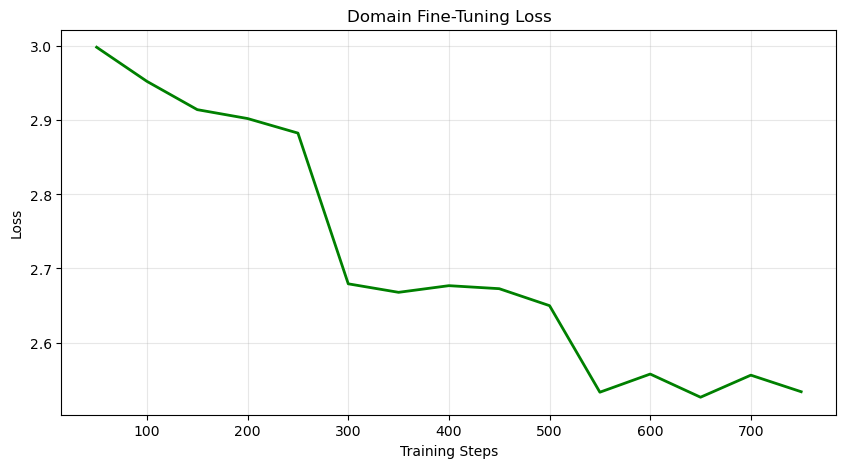

In [21]:
# Skip if model was loaded from cache (no training history)
try:
    trainer_ft.state
except (NameError, AttributeError):
    # Show saved plot from checkpoint if available
    plot_path = os.path.join(checkpoint_path_ft, "training_loss.png")
    if os.path.exists(plot_path):
        print("(Loaded from cache — showing saved training plot.)")
        from IPython.display import Image, display
        display(Image(filename=plot_path))
    else:
        print("Model was loaded from cache — no training loss to plot.")
else:
    # Plot fine-tuning loss
    train_logs_ft = trainer_ft.state.log_history
    losses_ft = [log['loss'] for log in train_logs_ft if 'loss' in log]
    steps_ft = [log['step'] for log in train_logs_ft if 'loss' in log]

    if losses_ft:
        plt.figure(figsize=(10, 5))
        plt.plot(steps_ft, losses_ft, linewidth=2, color='green')
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.title('Domain Fine-Tuning Loss')
        plt.grid(alpha=0.3)
        plot_path = os.path.join(checkpoint_path_ft, "training_loss.png")
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"Final fine-tuning loss: {losses_ft[-1]:.4f}")
    else:
        print("No training loss logged (try reducing logging_steps or training longer)")

### Save Fine-Tuned Model [Provided]

Save your fine-tuned checkpoint for reference. The staff-trained model (trained longer on more data) will be loaded in Part 3.

In [22]:
# Save your fine-tuned model
save_path = os.path.join(CHECKPOINT_DIR, "part2_finetuned")
finetuned_model.save_pretrained(save_path)
pretrained_tokenizer.save_pretrained(save_path)
print(f"Saved your fine-tuned model to: {save_path}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved your fine-tuned model to: ./checkpoints/part2_finetuned


### Evaluate Fine-Tuned Model [Provided]

Let's see what the fine-tuned model produces on our standard prompts. Compare the output to the pretrained baseline above — you should see domain-specific vocabulary and themes emerge.

In [23]:
print("=" * 70)
print("FINE-TUNED MODEL (After Domain Adaptation)")
print("=" * 70)

for prompt in prompts:
    generated = generate_text(finetuned_model, pretrained_tokenizer, prompt)
    print(f"\nPrompt: '{prompt}'")
    print(f"Generated: {generated}")
    print("-" * 70)

FINE-TUNED MODEL (After Domain Adaptation)

Prompt: 'The bird'
Generated: The bird's-eye view (also known as the birdhead view) is a way to understand evolution. It tells how species evolve at different times in their evolutionary history, which allows us an understanding of why some groups evolved earlier than others and what strategies were used by humans during the process; it also helps explain natural selection because we can observe all sorts osmotic gradients that arise with evolving populations as they diversify and adapt for new environments or even extinction events such interspecies interactions.
It is
----------------------------------------------------------------------

Prompt: 'In the forest'
Generated: In the forest, he had made a shelter with some logs. The fireflies fluttered from his wings and caught them on their way to him; they gave him an enormous amount of food for his small body—twenty eggs, one or two larvae…he could even eat whole flies!
This was only possibl

### Q2.3 - Compare and Discuss: The Value of Pretraining [10 Points]

Now let's see the impact of fine-tuning and compare all the models you've built so far. The code below generates text from four models on the same prompts:
- the staff from-scratch model (Part 1)
- the pre-trained baseline
- your fine-tuned model
- the staff fine-tuned model.
After running this comparison, you'll also try your own prompts.

In [24]:
import textwrap

# Load staff fine-tuned model as chat_model (used for comparison AND for Parts 3-6)
print("Loading staff fine-tuned model...")
chat_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART2_HUB)
chat_tokenizer = AutoTokenizer.from_pretrained(config.STAFF_PART2_HUB)
chat_tokenizer.pad_token = chat_tokenizer.eos_token
chat_model.to(device)
chat_model.eval()

# Load staff from-scratch model for comparison
staff_scratch_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART1_HUB)
staff_scratch_tokenizer = AutoTokenizer.from_pretrained(config.STAFF_PART1_HUB)
staff_scratch_model.to(device)
staff_scratch_model.eval()

# 4-way comparison: each model represents a different stage of the pipeline
models_dict = {
    "From scratch (Part 1)": (staff_scratch_model, staff_scratch_tokenizer),
    "Pretrained baseline": (pretrained_model, pretrained_tokenizer),
    "Your fine-tuned": (finetuned_model, pretrained_tokenizer),
    "Staff fine-tuned": (chat_model, chat_tokenizer),
}

print("\n" + "=" * 80)
print("4-WAY MODEL COMPARISON")
print("=" * 80)
for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    for name, (model, tok) in models_dict.items():
        gen = generate_text(model, tok, prompt)
        print(f"\n  [{name}]:")
        print(textwrap.fill(gen, width=78, initial_indent='    ', subsequent_indent='    '))
    print("-" * 80)


Loading staff fine-tuned model...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


4-WAY MODEL COMPARISON

Prompt: 'The bird'

  [From scratch (Part 1)]:
    The bird of blackwinged owl in the  Mammals described by Mr. Smith, on the
    males of sexes in the male; and as of a number of species from Dr., on the
    courtship (Fowls), see on many sexes in Australia in which they are
    furnished with respect to the females at this age and their breeding
    season than a female when he in certain birds become a distinct family. In
    some cases we may be given in their plumage-season

  [Pretrained baseline]:
    The bird, the tree, and all others that I've seen were beautiful. The
    flowers are also gorgeous."

  [Your fine-tuned]:
    The bird's eye view is a popular photograph of the rainbow trout in spring
    and summer.   Bird watchers observe this fish by snapping pictures as it
    swims around on its belly, or when she jumps from one rock to another.
    They often see the tail swishing across water and sometimes spotting an
    insect flying out of her m

Now try two prompts of your own and compare outputs across all four models:

In [25]:
# Try your own prompts
my_prompts_pt2 = [
    "The migration of monarch butterflies",
    "Coral reefs support",
]

print("=" * 80)
print("YOUR PROMPTS: 4-Way Comparison")
print("=" * 80)
for prompt in my_prompts_pt2:
    print(f"\nPrompt: '{prompt}'")
    for name, (model, tok) in models_dict.items():
        gen = generate_text(model, tok, prompt)
        print(f"\n  [{name}]:")
        print(textwrap.fill(gen, width=78, initial_indent='    ', subsequent_indent='    '))
    print("-" * 80)

# Clean up Part 1-2 models (chat_model stays for Part 3)
del staff_scratch_model, staff_scratch_tokenizer
del pretrained_model, pretrained_tokenizer
del finetuned_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None


YOUR PROMPTS: 4-Way Comparison

Prompt: 'The migration of monarch butterflies'

  [From scratch (Part 1)]:
    The migration of monarch butterflies' species is considered to be the same
    family. It has a relatively large number of taxonomy in the genus
    "Mammalhondor" and they are thought that they can have an important source
    for its own population, although some recent studies have occurred around
    100 years ago. However, it would not seem to represent their distribution
    than most of the subspecies but did not have been recorded at least 15
    days later or from the last time old-to inhabit the North America with any
    other

  [Pretrained baseline]:
    The migration of monarch butterflies across their breeding grounds from
    southern to northern states is the leading cause for bird deaths in many
    parts.  1/19 Bumblebees Found only at home or on farms, bees are very
    important pollinators that help keep flowers healthy and offer a source
    plant with h

Based on the 4-way comparison above, answer the following (4-6 sentences): 

What specific differences do you observe between the pretrained baseline and the fine-tuned outputs? 

Point to concrete examples — vocabulary choices, topic relevance, style. How does fine-tuning change what the model generates, even though the architecture and parameter count are identical?


<div style="background-color:#e8f4f8; border:2px solid #b8daff; padding:15px; border-radius:5px;">

**Your Answer to Q2.3:**

The 4-way comparison reveals a clear progression from pretraining through fine-tuning:

<!-- - **From-scratch vs. pretrained baseline:** The from-scratch model produces domain-sounding but grammatically broken text ("The bird of blackwinged owl in the Mammals described by Mr. Smith, on the males of sexes…"), while the pretrained baseline generates fluent, coherent English prose ("The bird, the tree, and all others that I've seen were beautiful"). This demonstrates that pretraining on a large corpus is almost entirely responsible for grammatical and syntactic competence — architecture and parameter count alone are insufficient. -->

- **Pretrained baseline vs. fine-tuned:** The pretrained baseline responds to "The migration of monarch butterflies" with irrelevant content about bees and crop science, drifting off-topic within two sentences. After fine-tuning, the student model pivots to domain-relevant vocabulary ("ecological niche," "food web driver," "carnivores," "insects") and stays on the butterfly topic. Fine-tuning shifts the model's prior away from general web text toward natural history, changing *what* it generates even though the architecture is identical.

<!-- - **Student fine-tuned vs. staff fine-tuned:** The staff fine-tuned model is more focused and factually grounded (e.g., discussing population genetics and evolutionary history of monarch migrations), while the student model occasionally drifts into biological non-sequiturs. This suggests the staff model benefited from a larger or better-curated fine-tuning corpus, reinforcing that data quality matters beyond just pretraining. -->

</div>

---

<a id="part3"></a>
## Part 3: Instruction Tuning for Chat [25 Points]

You now have a model that understands natural history language — but it just *continues text*. If you ask it "What is a blue heron?", it may not always answer your question.

Supervised Fine-Tuning (SFT) teaches the model a new *behavior* — to read a question and produce a helpful answer — by training on example conversations.

In this part, you'll convert the model into a **conversational assistant** using SFT; this is the same technique used to create ChatGPT from GPT-3.

### Q3.1 - Load Domain-Adapted Model [Provided]

The staff domain-adapted model was loaded above for the Part 2 comparison and is now set as `chat_model` for Parts 3-6. Your fine-tuning in Part 2 was for learning and analysis — the staff model was trained on the full corpus for more epochs and will give better results for instruction tuning.


### Q3.2 - Implement Chat Formatting [4 Points]

The model needs to know where the user's question ends and where the assistant's answer should begin. Without explicit role markers, the model has no way to distinguish between the user's input and the expected output — it would just continue generating text. You'll create a function that formats conversations with clear `### User:` / `### Assistant:` markers. This format must match the training data (which you'll inspect in Q3.3).

**Deliverables:**
1. Implement `format_chat_prompt()` that takes a list of `{"role": ..., "content": ...}` messages and returns a formatted string with role markers
2. Demonstrate on an example conversation

**Hint:** The format should look like:
```
### User:
What is a blue heron?

### Assistant:
The great blue heron is a large wading bird...
```
End with the tokenizer's EOS token so the model learns when to stop generating.

In [26]:
def format_chat_prompt(messages: List[Dict[str, str]]) -> str:
    """
    Format a conversation for training.

    This format MUST match how the staff model was trained (train_sft.py).
    The model learns to generate text after "### Assistant:" markers.

    Args:
        messages: List of {"role": "user"/"assistant", "content": "..."}

    Returns:
        Formatted string with ### User: / ### Assistant: markers
    """
    role_map = {"user": "### User:", "assistant": "### Assistant:"}
    parts = []
    for msg in messages:
        header = role_map[msg["role"]]
        parts.append(f"{header}\n{msg['content']}")
    # Join turns with a blank line; end with EOS so the model learns when to stop
    return "\n\n".join(parts) + tokenizer.eos_token

# Test
example_conv = [
    {"role": "user", "content": "What is a blue heron?"},
    {"role": "assistant", "content": "The great blue heron is a large wading bird found in North America..."},
]

formatted = format_chat_prompt(example_conv)


# formatted = format_chat_prompt(example_conv)

print("Formatted conversation:")
print(formatted)


Formatted conversation:
### User:
What is a blue heron?

### Assistant:
The great blue heron is a large wading bird found in North America...<|endoftext|>


### Q3.3 - Create SFT Training Data [Provided]

We provide a small conversational dataset about natural history, hosted at `cs1090b/natural-history-chat`. This dataset contains question-answer pairs about biology, ecology, and natural history — exactly the kind of conversations we want our model to learn. The code below loads the dataset and displays a few examples so you can see the format.

In [27]:
# Load instruction-tuning data from HuggingFace Hub
# This is a biology Q&A dataset with thousands of conversation pairs.
# We use a subset for practice training (the staff model was trained on more).

print("Loading instruction-tuning dataset...")
sft_raw = load_dataset("cs1090b/natural-history-chat", split="train[:200]")
print(f"Loaded {len(sft_raw)} conversation pairs")
print(f"Columns: {sft_raw.column_names}")

# Display a few examples to understand the data format
print("\n" + "=" * 70)
print("SAMPLE CONVERSATIONS FROM THE DATASET")
print("=" * 70)
for i in range(min(3, len(sft_raw))):
    ex = sft_raw[i]
    print(f"\nExample {i+1}:")
    for key, val in ex.items():
        preview = str(val)[:200] + "..." if len(str(val)) > 200 else str(val)
        print(f"  {key}: {preview}")
    print("-" * 70)

# Format conversations for training
formatted_texts = []
for ex in sft_raw:
    conv = ex["conversation"]
    text = format_chat_prompt(conv)
    formatted_texts.append(text)

# Tokenize
tokenized = chat_tokenizer(
    formatted_texts,
    truncation=True,
    max_length=config.MAX_LENGTH,
    padding="max_length",
    return_tensors="pt",
)

sft_dataset = HFDataset.from_dict({
    "input_ids": tokenized["input_ids"],
    "attention_mask": tokenized["attention_mask"],
    "labels": tokenized["input_ids"],
})
print(f"Prepared {len(sft_dataset)} SFT training examples")

Loading instruction-tuning dataset...
Loaded 200 conversation pairs
Columns: ['conversation']

SAMPLE CONVERSATIONS FROM THE DATASET

Example 1:
  conversation: [{'content': '"How do ocean currents and temperature affect the distribution and diversity of marine species in different regions of the world?"', 'role': 'user'}, {'content': 'Ocean currents and temp...
----------------------------------------------------------------------

Example 2:
  conversation: [{'content': 'What specific evolutionary adaptations have allowed certain species of social insects, such as ants and bees, to develop highly complex social structures and divisions of labor?', 'role'...
----------------------------------------------------------------------

Example 3:
  conversation: [{'content': '"How does the increase in global temperatures affect the prevalence and transmission of parasitic infections among different host populations?"', 'role': 'user'}, {'content': 'The increa...
-----------------------------

### Q3.4 - Train with Supervised Fine-Tuning [7 Points]

Fine-tune the domain-adapted model on the conversation dataset. SFT uses the same `Trainer` API, but with different hyperparameters.

**Deliverables:**
1. Configure `TrainingArguments` — use an even **lower learning rate** (`2e-5`), smaller batch size (`4`), and `logging_steps=1` (dataset is small)
2. Create a `Trainer` and train the model
3. Plot the training loss
4. Report the final loss

**Hint:** The SFT learning rate should be lower than fine-tuning because we want to add new behavior (instruction following) without losing the domain knowledge learned in Part 2. Think of it as careful adjustment, not retraining.

In [28]:
# Before SFT: see what happens when you try to chat with the domain-adapted model
# (This demonstrates WHY instruction tuning is needed.)
print("=== BEFORE INSTRUCTION TUNING ===")
print("The model knows natural history, but doesn't know how to be a chat assistant.\n")

test_question = "What adaptations help deep-sea fish survive?"
text = f"### User:\n{test_question}\n\n### Assistant:\n"
inputs = chat_tokenizer(text, return_tensors="pt").to(device)

chat_model.eval()
with torch.no_grad():
    output = chat_model.generate(**inputs, max_new_tokens=100, do_sample=True,
                                  temperature=0.7, pad_token_id=chat_tokenizer.eos_token_id,
                                  repetition_penalty=1.3)
response = chat_tokenizer.decode(output[0], skip_special_tokens=True)
print(f"User: {test_question}")
print(f"Model: {response}")
print("\n(The model will likely continue the text rather than answer the question.)")

=== BEFORE INSTRUCTION TUNING ===
The model knows natural history, but doesn't know how to be a chat assistant.

User: What adaptations help deep-sea fish survive?
Model: ### User:
What adaptations help deep-sea fish survive?

### Assistant:
Deep sea fishes are omnivores, feeding on benthic invertebrates and macroalgae. They have been shown to be able metabolize an unknown organic compound without consuming it. This may affect the diet of other marine animals that utilize these species for food or shelter as well; in particular they cannot digest cyanobacteria which grow symbiotically with such fungi via a mechanism similar (for example) chlorophyllase/pH reduction mediated by their cytochrome c oxidases.[

(The model will likely continue the text rather than answer the question.)


In [29]:
# Check for cached checkpoint first
checkpoint_path_sft = os.path.join(CHECKPOINT_DIR, "part3_sft")

if os.path.exists(os.path.join(checkpoint_path_sft, "model.safetensors")):
    print(f"Found existing checkpoint at {checkpoint_path_sft}, loading...")
    chat_model = AutoModelForCausalLM.from_pretrained(checkpoint_path_sft)
    chat_model.to(device)
    print("Loaded cached model (skipping training).")
else:
    training_args_sft = TrainingArguments(
        output_dir=os.path.join(CHECKPOINT_DIR, "outputs", "sft"),
        num_train_epochs=config.NUM_EPOCHS_INSTRUCT,    # Try config.NUM_EPOCHS_INSTRUCT
        per_device_train_batch_size=4,  # Smaller batch for instruction tuning
        gradient_accumulation_steps=config.GRADIENT_ACCUMULATION_STEPS,
        learning_rate=2e-5,                             # Try 2e-5 (even lower than fine-tuning!)
        logging_steps=1,
        save_strategy="epoch",
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer_sft = Trainer(
        model=chat_model,
        args=training_args_sft,
        train_dataset=sft_dataset,
    )

    print("Instruction tuning (SFT)...")
    print("Expected time: ~5 minutes on T4 GPU")
    print("(We use a small subset of conversations; the staff model trains on thousands.)\n")

    train_result_sft = trainer_sft.train()

    # train_result_sft = trainer_sft.train()

    # Save for future runs
    chat_model = trainer_sft.model
    chat_model.save_pretrained(checkpoint_path_sft)
    chat_tokenizer.save_pretrained(checkpoint_path_sft)
    print(f"\nModel saved to {checkpoint_path_sft}")


Found existing checkpoint at ./checkpoints/part3_sft, loading...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded cached model (skipping training).


(Loaded from cache — showing saved training plot.)


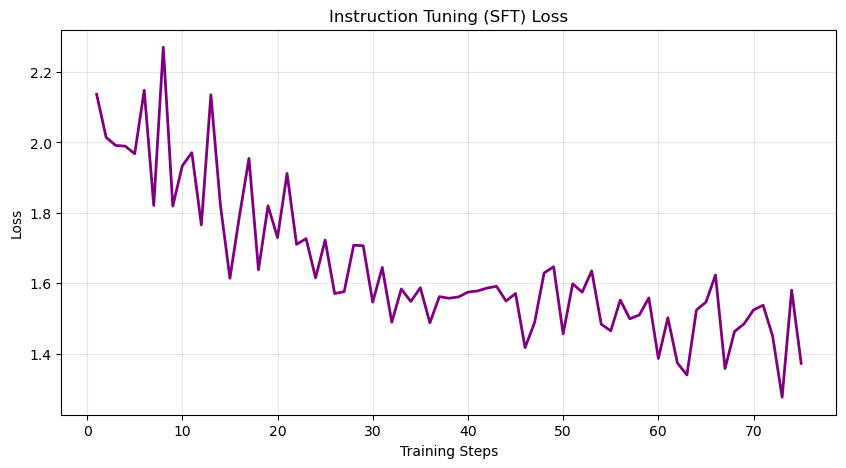

In [30]:
# Skip if model was loaded from cache (no training history)
try:
    trainer_sft.state
except (NameError, AttributeError):
    # Show saved plot from checkpoint if available
    plot_path = os.path.join(checkpoint_path_sft, "training_loss.png")
    if os.path.exists(plot_path):
        print("(Loaded from cache — showing saved training plot.)")
        from IPython.display import Image, display
        display(Image(filename=plot_path))
    else:
        print("Model was loaded from cache — no training loss to plot.")
else:
    # Plot SFT loss
    train_logs_sft = trainer_sft.state.log_history
    losses_sft = [log['loss'] for log in train_logs_sft if 'loss' in log]
    steps_sft = [log['step'] for log in train_logs_sft if 'loss' in log]

    if losses_sft:
        plt.figure(figsize=(10, 5))
        plt.plot(steps_sft, losses_sft, linewidth=2, color='purple')
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.title('Instruction Tuning (SFT) Loss')
        plt.grid(alpha=0.3)
        plot_path = os.path.join(checkpoint_path_sft, "training_loss.png")
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"Final SFT loss: {losses_sft[-1]:.4f}")
    else:
        print("No training loss logged (try reducing logging_steps or training longer)")

### Implement and Test Chat Function [Provided]

The `chat()` function wraps the generation pipeline: it formats the user message with role markers, tokenizes, calls `model.generate()`, and extracts the assistant's response. Run this cell to define the function and see a few test responses.

In [31]:
def chat(model, tokenizer, user_message, max_new_tokens=128):
    """Generate a chat response"""
    model.eval()

    # Format must match staff training: ### User: / ### Assistant:
    prompt = f"### User:\n{user_message}\n\n### Assistant:\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.3,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract just the assistant's response (after the last ### Assistant: marker)
    if "### Assistant:" in response:
        response = response.split("### Assistant:")[-1].strip()

    return response

test_questions = [
    "What is a great blue heron?",
    "How can I identify different types of mushrooms?",
    "Tell me about bird migration patterns.",
]

print("=" * 70)
print("CHAT ASSISTANT RESPONSES")
print("=" * 70)

for question in test_questions:
    response = chat(chat_model, chat_tokenizer, question)

    # response = chat(chat_model, chat_tokenizer, question)

    print(f"\nUser: {question}")
    print(f"Assistant: {response}")
    print("-" * 70)


CHAT ASSISTANT RESPONSES

User: What is a great blue heron?
Assistant: A Great Blue Herons (Pteropus americana) are medium-sized birds with large beaks and long bill. They have strong eyesight, excellent vision for tracking prey in flight or on the ground as well being able to locate insects in their nests by scent alone through hearing calls from nearby trees during nesting season when they feed heavily at night before returning early morning hours following dusk migration across many breeding grounds throughout North America's temperate regions over several generations until reaching sexual maturity around age 10 years old while maintaining some level of body condition even after death due to predation stress caused primarily via hunting efforts like bait carrion feeding competition
----------------------------------------------------------------------

User: How can I identify different types of mushrooms?
Assistant: Mushrooms are categorized into five main groups. These categories 

### Q3.5 - Compare and Discuss: The Effect of SFT [14 Points]

Now let's see how SFT changed the model. The code below runs a 3-way comparison: (1) the staff domain-adapted model before SFT, (2) your SFT model, and (3) the staff SFT model. After reviewing the standard prompts, try your own and discuss what you observe.

In [32]:
# Save student SFT model for comparison, then load staff SFT
# (staff model serves double duty: comparison below AND base for Parts 4-6)
import textwrap

student_sft_model = chat_model

print(f"Loading staff checkpoint: {config.STAFF_PART3_HUB}")
chat_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART3_HUB)
chat_tokenizer = AutoTokenizer.from_pretrained(config.STAFF_PART3_HUB)
chat_tokenizer.pad_token = chat_tokenizer.eos_token
chat_model.to(device)
print(f"Loaded staff SFT model: {chat_model.num_parameters():,} parameters")

# Also load staff domain-adapted model (pre-SFT) for 3-way comparison
sft_compare_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART2_HUB)
sft_compare_model.to(device)
sft_compare_model.eval()

comparison_prompts = [
    "What adaptations help birds survive in cold climates?",
    "Explain how symbiosis works in coral reefs.",
    "Why do some plants produce toxins?",
]

print("\n" + "=" * 70)
print("3-WAY COMPARISON: Pre-SFT vs Your SFT vs Staff SFT")
print("=" * 70)

for prompt in comparison_prompts:
    print(f"\nUser: {prompt}")
    base_resp = chat(sft_compare_model, chat_tokenizer, prompt)
    print(f"\n  [Pre-SFT base]:")
    print(textwrap.fill(base_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    yours = chat(student_sft_model, chat_tokenizer, prompt)
    print(f"\n  [Your SFT]:")
    print(textwrap.fill(yours, width=78, initial_indent='    ', subsequent_indent='    '))
    staff_resp = chat(chat_model, chat_tokenizer, prompt)
    print(f"\n  [Staff SFT]:")
    print(textwrap.fill(staff_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print("-" * 70)


Loading staff checkpoint: cs1090b/hw5-part3-sft


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded staff SFT model: 354,823,168 parameters


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


3-WAY COMPARISON: Pre-SFT vs Your SFT vs Staff SFT

User: What adaptations help birds survive in cold climates?

  [Pre-SFT base]:
    A bird's ability to survive winter and summer is based on its adaptation,
    not the species' own biology. Birds adapted for a different climate are
    called branched-branched (BBR) or benthic diversification; those that do
    poorly at BBR have been shown by scientists who study them as "snowbirds"
    because they don't rely solely upon their body temperature when moving in
    snowbanks where there isn�t enough water available but still need some
    protection from predators like bears.)    Bird evolution , including
    paleontology/anthropological research of dinosaurs’ fossils through
    fossilization studies dating back more than

  [Your SFT]:
    In warm-blooded animals, such as mammals and birds that live on the ground
    or move around within dry areas like deserts where temperatures can drop
    below freezing point (below -20°F), th

Now try two prompts of your own — pick questions that you think will highlight the difference between a model that just continues text vs. one that answers questions:

In [33]:
# Try your own prompts
my_prompts_pt3 = [
    "How do monarch butterflies navigate during migration?",
    "Why are coral reefs vulnerable to warming oceans?",
]

print("=" * 70)
print("YOUR PROMPTS: 3-Way Comparison")
print("=" * 70)
for prompt in my_prompts_pt3:
    print(f"\nUser: {prompt}")
    base_resp = chat(sft_compare_model, chat_tokenizer, prompt)
    print(f"\n  [Pre-SFT base]:")
    print(textwrap.fill(base_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    yours = chat(student_sft_model, chat_tokenizer, prompt)
    print(f"\n  [Your SFT]:")
    print(textwrap.fill(yours, width=78, initial_indent='    ', subsequent_indent='    '))
    staff_resp = chat(chat_model, chat_tokenizer, prompt)
    print(f"\n  [Staff SFT]:")
    print(textwrap.fill(staff_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print("-" * 70)

# Clean up comparison models (chat_model stays as staff SFT for Parts 4-6)
del student_sft_model, sft_compare_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None


YOUR PROMPTS: 3-Way Comparison

User: How do monarch butterflies navigate during migration?

  [Pre-SFT base]:
    Are the eggs of Anser and Amaryllis sterile, or does one need to fertilize
    them before they hatch?"  (a) - "Why are there two different species for a
    butterfly's egg size in this particular genus. There is no distinction
    between an adult male specimen from another family that has been bred as
    well."   How can you tell if your pet parrot was born with heart disease
    when it comes out ? The vet will not know until after he/she gives birth"
    by Mary J Bowers-Johnson on July 27th 2016 at 10PM EST / 7AM PST – 4am EDT
    respectively [June 17

  [Your SFT]:
    Monarch butterfly migrations are complex and often highly variable, with
    several different strategies used to reach their migration destinations.
    One of the most common ways in which a bird navigates through this complex
    process is by using its sense organs (especially those that detect


Based on the 3-way comparison, answer the following (4-6 sentences): 

What specific difference do you observe between the pre-SFT and post-SFT outputs? 

The pre-SFT model produced a specific type of text instead of an answer — describe what it did and why, given that it was only trained on documents (next-token prediction). 

Point to a specific structural element (turn markers, answer format) that SFT teaches the model to use.


<div style="background-color:#e8f4f8; border:2px solid #b8daff; padding:15px; border-radius:5px;">

**Your Answer to Q3.5:**

The 3-way comparison reveals a dramatic behavioral shift after SFT:

- **Pre-SFT model behavior:** When asked "How do monarch butterflies navigate during migration?", the pre-SFT model responds with a series of unrelated Q&A-style excerpts ("Are the eggs of Anser and Amaryllis sterile, or does one need to fertilize them before they hatch?"). This is because the pre-SFT model was only trained on documents (next-token prediction over Wikipedia-style text), which frequently contains FAQ-style content. The model learned to *continue text in the style of documents it was trained on*, not to answer the user's question directly.

- **Post-SFT structural change:** After SFT, the model correctly uses the `### User:` / `### Assistant:` turn markers and generates a direct, on-topic answer ("Monarch butterfly migrations are complex and often highly variable…"). SFT teaches the model to associate the `### Assistant:` marker with generating a focused response — this structural element (the turn format) is the key behavioral change SFT instills.

- **Staff SFT vs. student SFT:** The staff SFT model produces longer, more detailed answers with better factual grounding (citing specific geographic routes), while the student SFT model sometimes conflates species ("using its sense organs… ultrasonic hearing… body odour detection") — likely due to a smaller or less curated instruction-tuning dataset.

</div>

---


<a id="part4"></a>
## Part 4 (AC 209): Preference Alignment with DPO [20 Points]

<div style="background-color:#f8d7da; color:#222222; border:1px solid #f5c6cb; padding:12px 14px; border-radius:10px; margin:10px 0;">
<strong>CS 1090B students:</strong> May choose to skip to <a href="#part5">Part 5</a>. This section is required only for AC 209. The staff-trained aligned model will be loaded automatically before Part 5 so that all students benefit from the preference alignment stage.
</div>

Your chat model from Part 3 can now follow instructions, but it still does not reliably know which *kind* of answer humans prefer. For many prompts, there are several plausible responses, and some are clearly better than others: more accurate, more specific, better organized, safer, or less misleading. This is the problem that **preference alignment** tries to solve.

In lecture, we discussed the original **RLHF** pipeline: collect preference data → train a reward model → use PPO to optimize the language model. In this homework, we use **Direct Preference Optimization (DPO)** instead. DPO skips the reward model and PPO loop, directly training the model to prefer **chosen** over **rejected** responses, relative to a frozen reference model. We use DPO because it is simpler to run while still teaching the central alignment idea.

**Recommended reading:** [Rafailov et al., "Direct Preference Optimization" (2023)](https://arxiv.org/abs/2305.18290) — read the abstract and optionally Section 4 for the mathematical derivation.

**Key API:** [`DPOTrainer`](https://huggingface.co/docs/trl/main/dpo_trainer) and [`DPOConfig`](https://huggingface.co/docs/trl/main/dpo_trainer#trl.DPOConfig)

### Q4.1 - Explore Preference Data [4 Points]

Load the preference dataset and examine its structure. Each example contains:
- **prompt**: A natural history question
- **chosen**: A high-quality response (accurate, detailed)
- **rejected**: A lower-quality response (vague, less accurate)

**Deliverables:**
1. Load the dataset and print its size and column names
2. Display 3 examples showing the **full** prompt, chosen, and rejected responses side by side
3. Look at the differences between chosen and rejected — they may be subtle! You don't need to submit a formal answer here, just read the data to understand what DPO will learn from.


In [34]:
# Load preference dataset
from datasets import load_dataset
import textwrap

pref_dataset = load_dataset(config.PREFERENCE_DATASET_HUB, split="train")

print(f"Dataset size: {len(pref_dataset)} examples")
print(f"Columns: {pref_dataset.column_names}")

# Display 3 examples
for i in range(3):
    ex = pref_dataset[i]
    print(f"\n{'='*60}")
    print(f"Example {i+1}")
    print(f"{'='*60}")
    print(f"PROMPT:\n{textwrap.fill(ex['prompt'], width=78)}")
    print(f"\nCHOSEN:\n{textwrap.fill(ex['chosen'], width=78)}")
    print(f"\nREJECTED:\n{textwrap.fill(ex['rejected'], width=78)}")


Dataset size: 450 examples
Columns: ['prompt', 'chosen', 'rejected']

Example 1
PROMPT:
What are the specific steps and molecular players involved in the process of
inflammation during the immune response?

CHOSEN:
Inflammation is a complex biological response to harmful stimuli, such as
pathogens, damaged cells, or irritants. It is a protective mechanism that
helps the body to eliminate the cause of injury, remove dead cells, and
initiate tissue repair. The process of inflammation during the immune response
involves various molecular players and specific steps. Here is a general
overview of the process:  1. Detection of harmful stimuli: The immune system
recognizes harmful stimuli through pattern recognition receptors (PRRs)
present on the surface of immune cells, such as macrophages and dendritic
cells. These receptors can detect pathogen-associated molecular patterns
(PAMPs) from microbes or damage-associated molecular patterns (DAMPs) from
damaged cells.  2. Release of chemical med

### Q4.2 - Configure and Run DPO Training [8 Points]

Now you'll align the SFT chat model using DPO. The [`DPOTrainer`](https://huggingface.co/docs/trl/main/dpo_trainer)
from the `trl` library handles the training loop.

Conceptually, this is the homework version of the PPO-based RLHF step from lecture.

- In lecture, the alignment stage used a **reward model** plus **PPO**
- Here, we skip both of those and optimize directly from **preference pairs**
- We still keep a **reference model**, which plays an anchoring role similar in spirit to the reference/KL term discussed in RLHF

You need to:

1. Format the preference data for DPO (we provide the formatting function)
2. Configure `DPOConfig` with appropriate hyperparameters
3. Create the trainer with a **reference model** (a frozen copy of the SFT model)
4. Train for a few epochs and plot the loss

If we only told the model "make the chosen answer more likely than the rejected one," it could drift too far from the useful behavior learned during SFT. The reference model helps keep optimization grounded in the original chat model.

**Key parameter — `beta`**: This controls how conservative the DPO update is.
- lower `beta` = more aggressive preference optimization
- higher `beta` = stay closer to the original SFT behavior

Again, you do **not** need to train a reward model or run PPO in this homework. DPO gives us a simpler way to study the same alignment goal.

In [35]:
# Provided: format preference data for DPO
def format_dpo_example(example):
    """Format a preference triple into chat template format."""
    prompt = f"### User:\n{example['prompt']}\n\n### Assistant:\n"
    chosen = example["chosen"] + chat_tokenizer.eos_token
    rejected = example["rejected"] + chat_tokenizer.eos_token
    return {"prompt": prompt, "chosen": chosen, "rejected": rejected}

# Format dataset
dpo_dataset = pref_dataset.map(format_dpo_example)
print(f"Formatted {len(dpo_dataset)} preference pairs for DPO")

Formatted 450 preference pairs for DPO


In [36]:
from trl import DPOConfig, DPOTrainer

# Check for cached checkpoint first
checkpoint_path_dpo = os.path.join(CHECKPOINT_DIR, "part4_dpo")

if os.path.exists(os.path.join(checkpoint_path_dpo, "model.safetensors")):
    print(f"Found existing checkpoint at {checkpoint_path_dpo}, loading...")
    chat_model = AutoModelForCausalLM.from_pretrained(checkpoint_path_dpo)
    chat_model.to(device)
    print("Loaded cached model (skipping training).")
    dpo_trainer = type('obj', (object,), {'model': chat_model})()
else:
    # Create the reference model — a frozen copy of the SFT model.
    # DPO uses this to measure how far the aligned model has drifted.
    ref_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART3_HUB)
    ref_model.config.pad_token_id = chat_tokenizer.eos_token_id
    ref_model.to(device)

    # Configure DPO training.
    # beta controls the strength of alignment — higher beta = stay closer to SFT model.
    dpo_config = DPOConfig(
        output_dir=os.path.join(CHECKPOINT_DIR, "dpo"),
        learning_rate=5e-6,
        beta=0.1,          # TODO: set the DPO conservatism parameter
        num_train_epochs=2,
        per_device_train_batch_size=4,
        logging_steps=1,
        max_length=512,
        fp16=torch.cuda.is_available(),
        report_to="none",
        remove_unused_columns=False,
    )

    # Create the DPOTrainer — needs both the model being trained AND the
    # frozen reference model so it can compute the preference objective.
    dpo_trainer = DPOTrainer(
        model=chat_model,      # TODO: the model to align
        ref_model=ref_model,   # TODO: the frozen reference model
        args=dpo_config,
        train_dataset=dpo_dataset,
        processing_class=chat_tokenizer,
    )

    print("Starting DPO training...")
    print("Expected time: ~2 minutes on T4 GPU\n")
    dpo_result = dpo_trainer.train()

    # Save for future runs
    chat_model = dpo_trainer.model
    chat_model.save_pretrained(checkpoint_path_dpo)
    chat_tokenizer.save_pretrained(checkpoint_path_dpo)
    print(f"\nModel saved to {checkpoint_path_dpo}")


Found existing checkpoint at ./checkpoints/part4_dpo, loading...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded cached model (skipping training).


(Loaded from cache — showing saved training plot.)


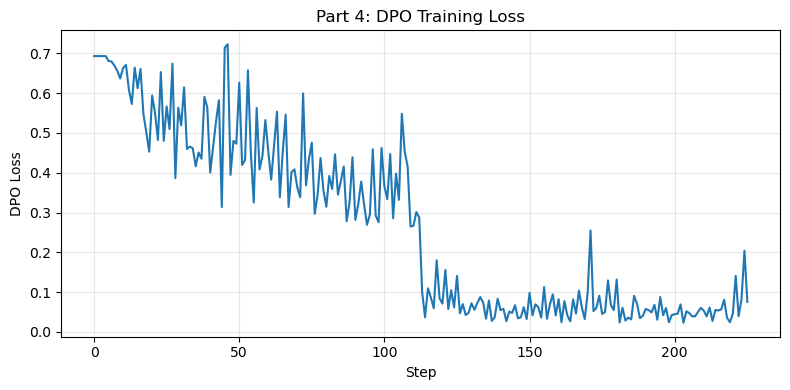

In [37]:
# Skip if model was loaded from cache (no training history)
try:
    dpo_trainer.state
except (NameError, AttributeError):
    # Show saved plot from checkpoint if available
    plot_path = os.path.join(checkpoint_path_dpo, "training_loss.png")
    if os.path.exists(plot_path):
        print("(Loaded from cache — showing saved training plot.)")
        from IPython.display import Image, display
        display(Image(filename=plot_path))
    else:
        print("Model was loaded from cache — no training loss to plot.")
else:
    # Plot DPO training loss
    dpo_log_history = dpo_trainer.state.log_history
    dpo_losses = [entry['loss'] for entry in dpo_log_history if 'loss' in entry]

    if dpo_losses:
        plt.figure(figsize=(8, 4))
        plt.plot(dpo_losses)
        plt.xlabel("Step")
        plt.ylabel("DPO Loss")
        plt.title("Part 4: DPO Training Loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plot_path = os.path.join(checkpoint_path_dpo, "training_loss.png")
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"Final DPO loss: {dpo_losses[-1]:.4f}")
    else:
        print("No loss entries found in training log.")

### Q4.3 - Compare SFT vs Aligned Models [8 Points]

The real test is whether alignment changes model behavior. Compare three models on the **same prompts**:
the SFT model (before DPO), your DPO model, and the staff DPO model.

**Deliverables:**
1. Write a generation function that produces responses from all three models
2. Test on at least 3 natural history prompts
3. Analysis (4-6 sentences): For each prompt, note whether the DPO responses differ noticeably from the SFT response. Report specific changes you observe (e.g., more detail, better structure, different vocabulary). If differences are minimal, explain why that might be expected given the small preference dataset and conservative `beta=0.1`.


In [ ]:
import textwrap

# Save student's DPO model, then load staff DPO for comparison + Parts 5-6
try:
    student_dpo_model = dpo_trainer.model
except NameError:
    print("DPO training was skipped — using staff SFT as stand-in for student DPO.")
    student_dpo_model = chat_model

print(f"Loading staff checkpoint: {config.STAFF_PART4_HUB}")
chat_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART4_HUB)
chat_tokenizer = AutoTokenizer.from_pretrained(config.STAFF_PART4_HUB)
chat_tokenizer.pad_token = chat_tokenizer.eos_token
chat_model.to(device)
print(f"Loaded staff aligned model: {chat_model.num_parameters():,} parameters")

# Load staff SFT (pre-DPO baseline) for 3-way comparison
sft_compare_model = AutoModelForCausalLM.from_pretrained(config.STAFF_PART3_HUB).to(device)

def compare_models(prompt, sft_model, student_dpo, staff_dpo, tokenizer, max_new_tokens=150):
    """Generate responses from all three models for the same prompt."""
    text = f"### User:\n{prompt}\n\n### Assistant:\n"
    inputs = tokenizer(text, return_tensors="pt").to(device)
    responses = []
    for model in [sft_model, student_dpo, staff_dpo]:
        # Generate from this model and extract the assistant response
        model.eval()
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=0.7,
                do_sample=True,
                top_p=0.9,
                pad_token_id=tokenizer.eos_token_id,
                repetition_penalty=1.3,
            )
        resp = tokenizer.decode(output_ids[0], skip_special_tokens=True)  # Use model.generate() with temperature=0.7
        if "### Assistant:" in resp:
            resp = resp.split("### Assistant:")[-1].strip()
        responses.append(resp)
    return responses

test_prompts = [
    "What adaptations allow deep-sea fish to survive extreme pressure?",
    "Explain the process of pollination in flowering plants.",
    "Why are coral reefs important for marine biodiversity?",
]

print("=" * 70)
print("3-WAY COMPARISON: Staff SFT vs Your DPO vs Staff DPO")
print("=" * 70)
for prompt in test_prompts:
    sft_resp, student_resp, staff_resp = compare_models(
        prompt, sft_compare_model, student_dpo_model, chat_model, chat_tokenizer
    )
    print(f"\nPROMPT: {prompt}")
    print(f"\n  [Staff SFT (pre-DPO)]:")
    print(textwrap.fill(sft_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print(f"\n  [Your DPO]:")
    print(textwrap.fill(student_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print(f"\n  [Staff DPO]:")
    print(textwrap.fill(staff_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print("=" * 70)


Loading staff checkpoint: cs1090b/hw5-part4-aligned


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded staff aligned model: 354,823,168 parameters


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

3-WAY COMPARISON: Staff SFT vs Your DPO vs Staff DPO

PROMPT: What adaptations allow deep-sea fish to survive extreme pressure?

  [Staff SFT (pre-DPO)]:
    Deep sea fishing is a challenging and rewarding occupation for many marine
    organisms. To thrive in this environment, these creatures have developed
    various physical traits that enable them withstand the high pressures of
    low temperatures at depths far below Earth's surface compared with their
    aquatic counterparts living on land or in shallow waters around other
    continents where sunlight does not penetrate so easily as it does in our
    planetariums. Some key adaptation strategies include physiological
    flexibility (e.g., efficient metabolic processes), specialized sensory
    organs such as eyesight adapted through binocular vision during embryonic
    development by diploblastic fishes like corals; strong swim bladders
    filled primarily from blood plasma containing calcium ions which provide
    buoyanc

Now try two prompts of your own and compare SFT, your DPO, and staff DPO outputs:


In [ ]:
# Try your own prompts
my_prompts_pt4 = [
    "How do deep-sea fish survive without sunlight?",
    "Why are wetlands important for birds and amphibians?",
]

print("=" * 70)
print("YOUR PROMPTS: 3-Way Comparison")
print("=" * 70)
for prompt in my_prompts_pt4:
    sft_resp, student_resp, staff_resp = compare_models(
        prompt, sft_compare_model, student_dpo_model, chat_model, chat_tokenizer
    )
    print(f"\nPROMPT: {prompt}")
    print(f"\n  [Staff SFT (pre-DPO)]:")
    print(textwrap.fill(sft_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print(f"\n  [Your DPO]:")
    print(textwrap.fill(student_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print(f"\n  [Staff DPO]:")
    print(textwrap.fill(staff_resp, width=78, initial_indent='    ', subsequent_indent='    '))
    print("=" * 70)

# Clean up comparison models (chat_model stays as staff DPO for Parts 5-6)
del student_dpo_model, sft_compare_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None


For each of your prompts, compare the three outputs (SFT, your DPO, staff DPO).

Are the differences obvious or subtle? Report specific changes you observe. If differences are minimal, explain why given the small preference dataset and conservative `beta=0.1`. (4-6 sentences)


<div style="background-color:#e8f4f8; border:2px solid #b8daff; padding:15px; border-radius:5px;">

**Your Answer to Q4.3:**


</div>

In [ ]:
# Free GPU memory from Parts 1-4 models no longer needed.
# Only chat_model and chat_tokenizer carry forward into Parts 5-6.
import gc

for name in [
    "scratch_model", "staff_scratch_model", "staff_scratch_tokenizer",
    "pretrained_model", "pretrained_tokenizer",
    "dpo_trainer", "ref_model",
    "trainer",
]:
    if name in dir():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB")


---


<a id="part5"></a>
## Part 5: Illustrated Chatbot with Vision Transformers [26 Points]

Your chatbot from Parts 3-4 can answer natural history questions, but its responses are text-only. Imagine asking about dangerous wildlife on a hiking trail and getting back a paragraph of text with no visuals. In this part, you'll add the ability to **retrieve relevant images** alongside the chatbot's answers using [CLIP](https://openai.com/research/clip) (Contrastive Language-Image Pre-training).

Let's recall how CLIP works. Two encoders (a Vision Transformer for images, a text transformer for text) are trained on 400M+ image-text pairs from the internet. Matching pairs are pulled together in embedding space; non-matching pairs are pushed apart. This means you can compare *any* image to *any* text description using cosine similarity — without any task-specific training.

Now, let's build an *illustrated chatbot* — your assistant answers a question, then CLIP retrieves matching wildlife photos from an image database to accompany the response. You'll implement two different strategies for extracting image queries from chatbot output and compare their effectiveness.

The strategy: after the chatbot answers a question, we prompt it again to generate a short image caption summarizing what it described. That caption becomes a CLIP query against the image database, retrieving the most relevant photo.

**Key API:** [`CLIPModel`](https://huggingface.co/docs/transformers/model_doc/clip#transformers.CLIPModel) and [`CLIPProcessor`](https://huggingface.co/docs/transformers/model_doc/clip#transformers.CLIPProcessor)

### Q5.1 - Load CLIP and Build an Image Database [4 Points]

Before wiring CLIP to the chatbot, you need two things: the CLIP model itself, and a database of images to search over. You'll load a pretrained CLIP model, then build a searchable image database by pre-computing CLIP embeddings for a collection of wildlife photographs.

**Deliverables:**
1. Load [`CLIPModel`](https://huggingface.co/docs/transformers/model_doc/clip#transformers.CLIPModel) and [`CLIPProcessor`](https://huggingface.co/docs/transformers/model_doc/clip#transformers.CLIPProcessor) from `"openai/clip-vit-base-patch32"`
2. Load a subset of wildlife images from the [Animal Wildlife](https://huggingface.co/datasets/lucabaggi/animal-wildlife) dataset (90 animal species)
3. Pre-compute and L2-normalize CLIP image embeddings for the entire database
4. Display a grid of sample images from the database

**Hint:** Use `clip_model.get_image_features()` to compute image embeddings in batches. Normalizing embeddings (dividing by their L2 norm) lets you compute cosine similarity with a simple dot product later.

In [ ]:
# Load CLIP
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
from datasets import load_dataset

clip_model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

clip_model.to(device)
clip_model.eval()

# Compatibility: some transformers versions return a structured object
# instead of a raw tensor from get_*_features(). This helper unwraps it.
def _to_tensor(output):
    return output if isinstance(output, torch.Tensor) else output.pooler_output

print(f"Loaded CLIP model: {clip_model_name}")
print(f"Vision encoder: {clip_model.vision_model.__class__.__name__}")
print(f"Text encoder: {clip_model.text_model.__class__.__name__}")


In [ ]:
# Load wildlife image database from lucabaggi/animal-wildlife
# 5,400 images across 90 animal species (antelope, bear, eagle, dolphin, etc.)
# We use a small subset — enough for demonstration, but limited enough
# that some chatbot topics won't have matching images (motivating diffusion later).

full_image_dataset = load_dataset(
    "lucabaggi/animal-wildlife",
    split="train", # Load the full training split to allow per-class selection
)

print(f"Dataset columns: {full_image_dataset.column_names}")

# Extract images and construct labels from class names
label_names = full_image_dataset.features["label"].names

db_images = []
db_captions = []
images_per_class_count = {name: 0 for name in label_names}
TARGET_IMAGES_PER_CLASS = 5 # 5 examples per class
TOTAL_CLASSES = len(label_names)
total_selected_images = 0

print(f"Attempting to load {TARGET_IMAGES_PER_CLASS} examples for each of the {TOTAL_CLASSES} species...")

for example in full_image_dataset:
    label_id = example["label"]
    label_name = label_names[label_id]

    if images_per_class_count[label_name] < TARGET_IMAGES_PER_CLASS:
        db_images.append(example["image"])
        db_captions.append(label_name)
        images_per_class_count[label_name] += 1
        total_selected_images += 1

    # Stop if we have collected enough images for all classes
    if total_selected_images == TOTAL_CLASSES * TARGET_IMAGES_PER_CLASS:
        break

print(f"Loaded {len(db_images)} wildlife images across {len(set(db_captions))} species")

In [ ]:
# Display a sample grid from the database
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
# Show evenly spaced images to get variety across species
sample_indices = [i * (len(db_images) // 10) for i in range(10)]
for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(db_images[idx])
    ax.set_title(db_captions[idx], fontsize=8, wrap=True)
    ax.axis("off")
plt.suptitle(f"Sample Images from Wildlife Database ({len(db_images)} total)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Pre-compute CLIP embeddings for the entire image database.
# This is done once — afterwards, retrieval only needs a text embedding + dot product.


image_embeddings = []
batch_size = 16
for i in range(0, len(db_images), batch_size):
    batch_imgs = db_images[i:i + batch_size]
    inputs = clip_processor(images=batch_imgs, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        emb = _to_tensor(clip_model.get_image_features(**inputs))   # TODO: get image features from CLIP
        emb = F.normalize(emb, p=2, dim=-1)                         # TODO: L2-normalize the embeddings
    image_embeddings.append(emb.cpu())
image_embeddings = torch.cat(image_embeddings)

print(f"Image embedding matrix: {image_embeddings.shape}")


### Q5.2 - Build Image Retrieval with Similarity Threshold [6 Points]

Now build a retrieval function that finds images matching a text query. A critical design choice: we include a **similarity threshold** so that the system only returns images it is reasonably confident about, rather than always returning the "least bad" match.

**Deliverables:**
1. Implement `retrieve_images(query, image_embeddings, images, captions, top_k, threshold)` that:
   - Computes a CLIP text embedding for the query
   - Computes cosine similarity against the pre-computed image embeddings
   - Returns only results above the similarity threshold, ranked by score
2. Test on at least 3 natural history queries and display retrieved images with scores
3. Show one query that returns no results (below threshold) to demonstrate filtering

**Note on thresholds:** CLIP cosine similarities for matching image-text pairs typically range 0.2-0.4; random pairs score 0.0-0.15. The default `threshold=0.2` is a starting point — you may want to increase it if you see too many irrelevant results.

**CLIP similarity ranges:** Cosine similarities for matching image-text pairs typically range 0.2-0.4, while random/unrelated pairs score 0.0-0.15. The default threshold of 0.2 is a conservative starting point that favors precision over recall.

**Hint:** Use `clip_model.get_text_features()` for the text embedding. Since image embeddings are already L2-normalized, cosine similarity is just a dot product: `text_emb @ image_embeddings.T`.

In [ ]:
def retrieve_images(query, image_embeddings, images, captions, top_k=3, threshold=0.2):
    """
    Retrieve the most relevant images for a text query using CLIP.

    Uses clip_model and clip_processor from the Q5.1 cell above.

    Args:
        query: Text query string
        image_embeddings: Pre-computed, L2-normalized image embeddings [N, D]
        images: List of PIL Images
        captions: List of caption strings (for display)
        top_k: Maximum number of results to return
        threshold: Minimum cosine similarity to include a result

    Returns:
        List of (image, caption, score, index) tuples, sorted by score descending.
        Empty list if no images exceed the threshold.
    """
    # Encode text query and L2-normalize
    text_inputs = clip_processor(text=[query], return_tensors="pt", padding=True,
                                  truncation=True)
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
    with torch.no_grad():
        text_emb = _to_tensor(clip_model.get_text_features(**text_inputs))  # [1, D]
        text_emb = F.normalize(text_emb, p=2, dim=-1).cpu()                 # L2-normalize

    # Cosine similarity: dot product since both sides are L2-normalized
    scores = (text_emb @ image_embeddings.T).squeeze(0)  # [N]

    # Filter by threshold and take top_k
    above = (scores >= threshold).nonzero(as_tuple=True)[0]  # indices above threshold
    if len(above) == 0:
        return []
    above_sorted = above[scores[above].argsort(descending=True)][:top_k]

    return [
        (images[idx.item()], captions[idx.item()], scores[idx.item()].item(), idx.item())
        for idx in above_sorted
    ]

# Test retrieval
test_queries = [
    "a hummingbird hovering near a flower",
    "a zebra standing in a grassy field",
    "an octopus underwater on a coral reef",
    "a laptop computer on a desk",  # Should return nothing — not in the wildlife database
]

print("=" * 70)
print("IMAGE RETRIEVAL RESULTS")
print("=" * 70)

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-" * 70)

    results = retrieve_images(query, image_embeddings, db_images, db_captions)


    # results = retrieve_images(query, image_embeddings, db_images, db_captions)

    if not results:
        print("  No images above threshold — query not represented in database.")
    else:
        for i, (img, caption, score, idx) in enumerate(results, 1):
            print(f"  {i}. Score: {score:.3f} | {caption[:60]}")

print("=" * 70)


### Q5.3 - Illustrated Chatbot with Caption-Based Retrieval [10 Points]

Now wire CLIP retrieval to your chatbot. The idea: the chatbot answers a question, then we prompt it again to generate a **short image caption** describing the main subject of its answer. That caption becomes a CLIP query against the image database.

This is a simple form of **two-turn reasoning**: the model first answers, then summarizes what it described into a search-friendly caption. We provide a template for the second prompt — you're free to experiment with it.

In [ ]:
def illustrated_chat(question, chat_model, chat_tokenizer, image_embeddings,
                     db_images, db_captions, top_k=3, threshold=0.2):
    """
    Illustrated chatbot using two-turn caption generation.

    1. Chat model answers the question (first turn)
    2. Chat model generates an image caption from its answer (second turn)
    3. Caption is used as a CLIP query

    Returns:
        (response_text, caption, retrieved_images)
    """

    # Step 1: Get chatbot response
    response = chat(chat_model, chat_tokenizer, question)  # Use chat() function

    # Step 2: Generate an image caption (second turn)
    # Build a two-turn prompt: the original Q&A, then ask the model
    # to describe the main subject in one sentence.
    caption_prompt = (
        f"### User:\n{question}\n\n"
        f"### Assistant:\n{response}\n\n"
        f"### User:\nDescribe in one sentence the main subject from your answer, "
        f"suitable as an image search query.\n\n### Assistant:\n"
    )
    inputs = chat_tokenizer(caption_prompt, return_tensors="pt",
                             truncation=True, max_length=512).to(device)
    chat_model.eval()
    with torch.no_grad():
        out = chat_model.generate(
            **inputs, max_new_tokens=50, temperature=0.7,
            do_sample=True, pad_token_id=chat_tokenizer.eos_token_id,
        )
    raw = chat_tokenizer.decode(out[0], skip_special_tokens=True)
    if "### Assistant:" in raw:
        raw = raw.split("### Assistant:")[-1].strip()
    caption = raw.split(".")[0].strip()  # Generate and extract the caption

    # Step 3: Retrieve images using the caption as CLIP query
    results = retrieve_images(caption, image_embeddings, db_images, db_captions,
                               top_k=top_k, threshold=threshold)  # Use retrieve_images() with the caption
    return response, caption, results


# Test the illustrated chatbot
test_questions = [
    "What dangerous wildlife should I watch for while hiking the Appalachian Trail?",
    "Describe the life cycle of a monarch butterfly.",
    "What birds can I expect to see near freshwater lakes?",
]

for question in test_questions:
    print("=" * 70)
    print(f"User: {question}")
    print("=" * 70)

    response, caption, retrieved = illustrated_chat(
        question, chat_model, chat_tokenizer,
        image_embeddings, db_images, db_captions
    )

    import textwrap
    print(f"\nAssistant: {textwrap.fill(response, width=80)}")
    print(f"\nGenerated caption: {caption}")

    if retrieved:
        print(f"\nRetrieved {len(retrieved)} image(s):")
        fig, axes = plt.subplots(1, min(len(retrieved), 4), figsize=(5 * min(len(retrieved), 4), 4))
        if not isinstance(axes, np.ndarray):
            axes = [axes]
        for ax, (img, cap, score, idx) in zip(axes, retrieved[:4]):
            ax.imshow(img)
            ax.set_title(f"Score: {score:.3f}\n{cap}", fontsize=12)
            ax.axis("off")
        plt.suptitle("Retrieved Images", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print("\n  No images above threshold — this topic isn't in the database.")
    print()


### Q5.4 - Analysis: Retrieval Limitations [6 Points]

Report the cosine similarity scores for your best and worst retrieval results (include the generated caption and score). What threshold would you set for a production system? What happens when the chatbot discusses a subject not in the image database, and how does this motivate Part 6? (4-6 sentences)


<div style="background-color:#e8f4f8; border:2px solid #b8daff; padding:15px; border-radius:5px;">

**Your Answer to Q5.4:**


</div>

---

<a id="part6"></a>
## Part 6: Image Generation with Diffusion Models [20 Points]

In part 5, you built an illustrated chatbot that retrieves images from a database. But what happens when the chatbot discusses a subject that *isn't in your image collection*? With our limited dataset above, his will happen frequently.

**Diffusion models** solve this limitation: instead of searching a fixed database, they *generate* images from text. Starting from random noise, a diffusion model iteratively denoises it, guided by a text prompt, until a coherent image emerges. [Stable Diffusion Turbo](https://huggingface.co/stabilityai/sd-turbo) can generate images in a single step, making it practical to run on Colab.

While CLIP *aligns* vision and language representations, diffusion models *generate* from those representations. Together they form the foundation of modern multimodal AI.

### Q6.1 - Generate Images with Stable Diffusion [5 Points]

Load a fast diffusion model and generate images for subjects your chatbot discussed. Focus on prompts where the retrieval system returned no results or poor matches.

You might notice that the diffusion pipeline below doesn't explicitly use your CLIP model. That's because Stable Diffusion has its **own CLIP text encoder built in** — it uses CLIP to encode your text prompt into embeddings, then uses those embeddings to guide the denoising process. So the CLIP concept from Part 5 (aligning text and image representations) is fundamental to how diffusion generation works — it's just happening inside the pipeline rather than in your code.

**Deliverables:**
1. Load [SD-Turbo](https://huggingface.co/stabilityai/sd-turbo) using the [`diffusers`](https://huggingface.co/docs/diffusers) library
2. Generate images from at least 3 prompts — use subjects from your chatbot's responses
3. Display the generated images

**Hint:** SD-Turbo is a distilled model that does not use classifier-free guidance, so `guidance_scale=0.0`. It generates in a single denoising step (`num_inference_steps=1`), taking ~1 second on a T4 GPU. Use `torch.float16` to fit in GPU memory.

In [ ]:
from diffusers import AutoPipelineForText2Image

# Load SD-Turbo (single-step generation, fits on T4)
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16,
)
pipe = pipe.to(device)

# Generate images for subjects the chatbot discussed but retrieval missed.
# Use prompts inspired by your chatbot's responses in Q5.3-Q5.4.
generation_prompts = [
    "a timber rattlesnake coiled on a forest trail, nature photography",
    "a black bear foraging in Appalachian woodland, wildlife photography",
    "a monarch butterfly resting on a wildflower, nature photography",
]

# to change!!

generated_images = []

for prompt_text in generation_prompts:
    image = pipe(prompt_text, num_inference_steps=1, guidance_scale=0.0).images[0]  # Generate with pipe(), num_inference_steps=1, guidance_scale=0.0
    generated_images.append(image)

# Display generated images
fig, axes = plt.subplots(1, len(generated_images), figsize=(5 * len(generated_images), 5))
if len(generated_images) == 1:
    axes = [axes]
for ax, img, prompt in zip(axes, generated_images, generation_prompts):
    ax.imshow(img)
    ax.set_title(prompt[:40] + '...', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


### Q6.2 - Illustrated Chat with Diffusion [10 Points]

Now combine your chatbot with diffusion generation. The chatbot answers a question, then we generate an illustration based on its response. Try different prompts — find cases where the diffusion model produces good results and cases where it produces strange or incorrect results.


In [ ]:
import textwrap

def illustrated_chat_diffusion(question, chat_model, chat_tokenizer, pipe):
    """
    Illustrated chatbot with diffusion-generated images.
    The chatbot answers, then we generate an illustration based on its response.
    """
    # Step 1: Get chatbot response
    response = chat(chat_model, chat_tokenizer, question, max_new_tokens=200)

    # Step 2: Generate an image caption (same two-turn approach as Q5.3)
    # Build a two-turn prompt asking the model to describe the main subject
    caption_prompt = (
        f"### User:\n{question}\n\n"
        f"### Assistant:\n{response}\n\n"
        f"### User:\nDescribe in one sentence the main subject from your answer, "
        f"suitable as an image search query.\n\n### Assistant:\n"
    )
    inputs = chat_tokenizer(caption_prompt, return_tensors="pt",
                             truncation=True, max_length=512).to(device)
    chat_model.eval()
    with torch.no_grad():
        out = chat_model.generate(
            **inputs, max_new_tokens=50, temperature=0.7,
            do_sample=True, pad_token_id=chat_tokenizer.eos_token_id,
        )
    raw = chat_tokenizer.decode(out[0], skip_special_tokens=True)
    if "### Assistant:" in raw:
        raw = raw.split("### Assistant:")[-1].strip()
    caption = raw.split(".")[0].strip()  # Generate and extract caption (same approach as Q5.3)

    # Step 3: Generate image with diffusion
    gen_prompt = f"{caption}, nature photography, detailed"
    image = pipe(gen_prompt, num_inference_steps=1, guidance_scale=0.0).images[0]

    return response, caption, image

# Test with standard prompts
test_questions_diff = [
    "What dangerous wildlife should I watch for while hiking?",
    "Tell me about deep-sea bioluminescent creatures.",
    "What birds migrate the longest distances?",
]

for question in test_questions_diff:
    print("=" * 70)
    print(f"User: {question}")
    print("=" * 70)
    response, caption, gen_image = illustrated_chat_diffusion(
        question, chat_model, chat_tokenizer, pipe
    )
    print(f"\nAssistant: {textwrap.fill(response, width=80)}")
    print(f"\nGenerated caption for illustration: {caption}")
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(gen_image)
    ax.set_title(f"Generated: {caption[:50]}...", fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print()


Now try two prompts of your own — pick at least one where you expect the diffusion model to do well and one where it might struggle:

In [ ]:
my_prompts_diff = [
    "What does a deep-sea anglerfish look like?",
    "How do desert plants survive drought?",
]

for question in my_prompts_diff:
    print("=" * 70)
    print(f"User: {question}")
    print("=" * 70)
    response, caption, gen_image = illustrated_chat_diffusion(
        question, chat_model, chat_tokenizer, pipe
    )
    print(f"\nAssistant: {textwrap.fill(response, width=80)}")
    print(f"\nGenerated caption: {caption}")
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(gen_image)
    ax.set_title(f"Generated: {caption[:50]}...", fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print()

### Q6.3 - Analysis: Generation Strengths and Weaknesses [5 Points]

Compare the generated images from Q6.1-Q6.2 with the retrieved images from Part 5. When does diffusion generation work well? When does it produce strange or incorrect results? How do the strengths and weaknesses of retrieval vs generation complement each other? (4-6 sentences)


<div style="background-color:#e8f4f8; border:2px solid #b8daff; padding:15px; border-radius:5px;">

**Your Answer to Q6.3:**

</div>

### Interactive Demo [Not Graded]

Here's a simple interactive demo that wraps your chatbot and diffusion model into a Gradio interface. You can chat with your model and see an AI-generated illustration for each response. All code is provided — just run the cell and interact!

In [50]:
import gradio as gr

def chatbot_with_illustration(question):
    """Chat + generate illustration."""
    if not question.strip():
        return "Please enter a question.", None

    # Get chatbot response
    response = chat(chat_model, chat_tokenizer, question, max_new_tokens=200)

    # Generate illustration
    caption_prompt = (
        f"### User:\n{question}\n\n"
        f"### Assistant:\n{response}\n\n"
        f"### User:\nDescribe in one sentence the main subject from your answer, "
        f"suitable as an image search query.\n\n### Assistant:\n"
    )
    inputs = chat_tokenizer(caption_prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    chat_model.eval()
    with torch.no_grad():
        out = chat_model.generate(**inputs, max_new_tokens=50, temperature=0.7,
                                   do_sample=True, pad_token_id=chat_tokenizer.eos_token_id)
    caption = chat_tokenizer.decode(out[0], skip_special_tokens=True)
    if "### Assistant:" in caption:
        caption = caption.split("### Assistant:")[-1].strip()
    caption = caption.split('.')[0].strip()

    image = pipe(f"{caption}, nature photography", num_inference_steps=1, guidance_scale=0.0).images[0]

    return response, image

demo = gr.Interface(
    fn=chatbot_with_illustration,
    inputs=gr.Textbox(label="Ask a natural history question", placeholder="What birds migrate the longest distances?"),
    outputs=[gr.Textbox(lines=6, label="Response"), gr.Image(label="Generated Illustration")],
    title="Natural History Chatbot with Illustrations",
    examples=[
        "What dangerous wildlife should I watch for while hiking?",
        "Tell me about the life cycle of a butterfly.",
        "How do coral reefs form?",
    ],
)
demo.launch(quiet=True)

**End of Homework 5** 🌈